## Data Integration & Abusing Detection

In [1]:
import pandas as pd
import numpy as np

## STEP 1. Data Load & Basic Preprocessing

In [2]:
df_master    = pd.read_csv('/Users/joshuakim/Desktop/프로젝트 데이터 모음/아이브코리아/최종 프로젝트 코드 모음/아이브 코리아 데이터/광고 목록_도메인 라벨링_결측치처리.csv', low_memory=False)
df_reward    = pd.read_csv('/Users/joshuakim/Desktop/프로젝트 데이터 모음/아이브코리아/최종 프로젝트 코드 모음/아이브 코리아 데이터/IVE_광고적립_all.csv', low_memory=False)
df_engagement= pd.read_csv('/Users/joshuakim/Desktop/프로젝트 데이터 모음/아이브코리아/최종 프로젝트 코드 모음/아이브 코리아 데이터/IVE_광고참여정보_all.csv', low_memory=False)
df_report    = pd.read_csv('/Users/joshuakim/Desktop/프로젝트 데이터 모음/아이브코리아/최종 프로젝트 코드 모음/아이브 코리아 데이터/아이브시간대별ad리포트_1년치_all.csv', low_memory=False)

In [3]:
# ─────────────────────────────────────────────────────────
# Analysis period constants — shared across all code
# ─────────────────────────────────────────────────────────
ANALYSIS_START = pd.to_datetime('2025-07-26')
ANALYSIS_END   = pd.to_datetime('2025-08-25')

# df_master: date type conversion + edate upper bound correction
for col in ['regdate', 'ads_sdate', 'ads_edate']:
    df_master[col] = pd.to_datetime(df_master[col], errors='coerce')
df_master['ads_edate'] = df_master['ads_edate'].clip(upper=pd.to_datetime('2025-08-29'))

# df_master2: STEP 2의 비용 Remove outliers 전 전체 행 보존 복사본.
# CTIT 중앙값 계산, df_integrated·df_report 조인 등 원본 행이 필요한 곳에 사용.
# df_master는 이후 STEP 2에서 이상치 행이 제거되므로 두 버전을 분리하여 관리.
df_master2 = df_master.copy()

type_map = {
    1:'install', 2:'launch', 3:'participation', 4:'click_type',
    5:'facebook', 6:'twitter', 7:'instagram', 8:'display',
    9:'quest', 10:'youtube', 11:'naver', 12:'CPS(purchase)'
}
domain_map = {1:'entertainment', 2:'finance', 3:'lifestyle', 4:'commerce', 5:'other'}

df_master2['ads_type_name'] = df_master2['ads_type'].map(type_map)
df_master2['domain_name']   = df_master2['domain_label'].map(domain_map)

df_reward['advid'] = df_reward['advid'].fillna('Unknown')

df_engagement = (
    df_engagement
    .drop(columns=['carrier'])
    .assign(network=lambda x: x['network'].fillna('Unknown'))
    .dropna(subset=['user_ip'])
    .reset_index(drop=True)
)

/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_86352/1681249805.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_master[col] = pd.to_datetime(df_master[col], errors='coerce')


## STEP 2. Cost Structure Outlier Removal

Cost flow principle: S(advertiser) ≥ A(IVE) ≥ Earn(media) ≥ RWD(user), all positive.  
Rows violating this or with cost=0 are removed as data errors.

In [4]:
df_master = df_master[
    (df_master['ads_contract_price'] >= df_master['ads_reward_price']) &
    (df_master['ads_contract_price'] > 0) &
    (df_master['ads_reward_price']   > 0)
].reset_index(drop=True)

df_engagement = df_engagement[
    (df_engagement['adv_price']      >= df_engagement['contract_price']) &
    (df_engagement['contract_price'] >= df_engagement['media_price']) &
    (df_engagement['media_price']    >= df_engagement['reward_price']) &
    (df_engagement[['adv_price', 'contract_price', 'media_price']].min(axis=1) > 0)
].reset_index(drop=True)

df_reward = df_reward[
    (df_reward['show_cost'] >= df_reward['adv_cost']) &
    (df_reward['adv_cost']  >= df_reward['earn_cost']) &
    (df_reward['earn_cost'] >= df_reward['rwd_cost']) &
    (df_reward[['show_cost', 'adv_cost', 'earn_cost']].min(axis=1) > 0)
].reset_index(drop=True)

# reward에만 있고 engagement에 없는 이상 케이스 제거
valid_click_keys = set(df_engagement['click_key'])
before = len(df_reward)
df_reward = df_reward[df_reward['click_key'].isin(valid_click_keys)].reset_index(drop=True)
print(f"reward 이상케이스 제거: {before:,} → {len(df_reward):,} (제거 {before - len(df_reward)}건)")

reward 이상케이스 제거: 1,470,614 → 1,470,533 (제거 81건)


## STEP 3. Feature Engineering

**CTIT outlier labeling**: Lower bound = type-specific median × 0.1. For click_type (type=4), CTIT=0 is an error.

**IP stats**: From the same IP 비정상적으로 많은 기기·클릭 수 = 어뷰징 의심.

In [5]:
# CTIT 이상치 라벨링
ctit_tmp = df_reward[['ads_idx', 'ctit']].merge(
    df_master2[['ads_idx', 'ads_type']], on='ads_idx', how='left'
)
threshold_map = (
    ctit_tmp[ctit_tmp['ads_type'] != 4]
    .groupby('ads_type')['ctit'].median() * 0.1
).to_dict()

ctit_tmp['threshold'] = ctit_tmp['ads_type'].map(threshold_map)
is_ctit_error = (
    ((ctit_tmp['ads_type'] == 4) & (ctit_tmp['ctit'] == 0)) |
    ((ctit_tmp['ads_type'] != 4) & (ctit_tmp['ctit'] < ctit_tmp['threshold']))
)
df_reward['ctit_error'] = np.where(is_ctit_error.values, 'Y', 'N')

# Aggregate device count / click count per IP
ip_stats = (
    df_engagement
    .groupby(['mda_idx', 'user_ip'])
    .agg(
        device_count=('dvc_idx',   'nunique'),
        click_count =('click_key', 'count')
    )
    .reset_index()
)

## STEP 4. Build Integrated DataFrame

engagement(clicks) + reward(conversions) + master(ad info) + ip_stats(IP stats) join.  
`is_rewarded`: ctit가 존재하면 conversion 완료(적립 발생) = 비용 청구 대상.

In [6]:
df_integrated = (
    df_engagement
    .merge(df_reward,    on='click_key',             how='left', suffixes=('', '_reward'))
    .merge(df_master2,   on='ads_idx',               how='left', suffixes=('', '_master'))
    .merge(ip_stats,     on=['mda_idx', 'user_ip'],  how='left')
)
df_integrated['is_rewarded'] = df_integrated['ctit'].notna().astype(int)

## STEP 5. Row-level Abusing Classification (row_label)

**Grade criteria (percentile)**
| 등급 | 기준 |
|------|------|
| outlier | Top 0.1% → confirmed abusing |
| 위험   | 상위 1.0% 초과 |
| 경고   | 상위 5.0% 초과 |
| 정상   | 상위 5.0% 이하 |

**가중치**: CTIT 50% / IP기기수 30% / IPclick_count 20%

**row_label**
- `미적립`: is_rewarded == 0
- `극단값`: 3개 Metric 중 하나라도 극단값
- `어뷰징`: 극단값 아닌데 경고/위험 Metric 존재
- `정상`: 모든 Metric 정상

In [7]:
# 분위수 기준값 산출
d_crit = ip_stats['device_count'].quantile(0.999)
d_dang = ip_stats['device_count'].quantile(0.99)
d_warn = max(2, ip_stats['device_count'].quantile(0.95))

c_crit = ip_stats['click_count'].quantile(0.999)
c_dang = ip_stats['click_count'].quantile(0.99)
c_warn = ip_stats['click_count'].quantile(0.95)

print(f"[Device count threshold]  normal: ≤{d_warn:.0f}  warning: ~{d_dang:.0f}  risky: ~{d_crit:.0f}  outlier: >{d_crit:.0f}")
print(f"[Click count threshold]  normal: ≤{c_warn:.0f}  warning: ~{c_dang:.0f}  risky: ~{c_crit:.0f}  outlier: >{c_crit:.0f}")

# ip_stats에 등급 부여
ip_stats['device_grade'] = np.select(
    [ip_stats['device_count'] <= d_warn,
     ip_stats['device_count'] <= d_dang,
     ip_stats['device_count'] <= d_crit],
    ['normal', 'warning', 'risky'], default='outlier'
)
ip_stats['click_grade'] = np.select(
    [ip_stats['click_count'] <= c_warn,
     ip_stats['click_count'] <= c_dang,
     ip_stats['click_count'] <= c_crit],
    ['normal', 'warning', 'risky'], default='outlier'
)
print(f"\n[device_grade distribution]\n{ip_stats['device_grade'].value_counts()}")
print(f"\n[click_grade distribution]\n{ip_stats['click_grade'].value_counts()}")

[기기 수 기준]  정상: ≤3  경고: ~6  위험: ~88  극단값: >88
[클릭 수 기준]  정상: ≤37  경고: ~258  위험: ~934  극단값: >934

[device_grade 분포]
device_grade
정상     928378
경고      24852
위험       7987
극단값       957
Name: count, dtype: int64

[click_grade 분포]
click_grade
정상     914222
경고      38340
위험       8649
극단값       963
Name: count, dtype: int64


In [8]:
# df_integrated에 IP 등급 조인
df_integrated = df_integrated.merge(
    ip_stats[['mda_idx', 'user_ip', 'device_grade', 'click_grade']],
    on=['mda_idx', 'user_ip'], how='left'
)
df_integrated['device_grade'] = df_integrated['device_grade'].fillna('normal')
df_integrated['click_grade']  = df_integrated['click_grade'].fillna('normal')

# CTIT 등급 부여
df_integrated['ctit_grade'] = np.select(
    [df_integrated['ctit_error'].isna(),
     df_integrated['ctit_error'] == 'Y',
     df_integrated['ctit_error'] == 'N'],
    ['non_rewarded', 'outlier', 'normal'], default='non_rewarded'
)
print(f"[ctit_grade distribution]\n{df_integrated['ctit_grade'].value_counts()}")

# Grade → score conversion
grade_score_map = {'normal': 100, 'non_rewarded': 100, 'warning': 70, 'risky': 40, 'outlier': 10}
df_integrated['ctit_score']   = df_integrated['ctit_grade'].map(grade_score_map)
df_integrated['device_score'] = df_integrated['device_grade'].map(grade_score_map)
df_integrated['click_score']  = df_integrated['click_grade'].map(grade_score_map)

# Weighted score: CTIT 50% + IP기기수 30% + IPclick_count 20%
df_integrated['row_score'] = (
    df_integrated['ctit_score']   * 0.50 +
    df_integrated['device_score'] * 0.30 +
    df_integrated['click_score']  * 0.20
)

is_ctit_extreme   = df_integrated['ctit_grade']   == 'outlier'
is_device_extreme = df_integrated['device_grade'] == 'outlier'
is_click_extreme  = df_integrated['click_grade']  == 'outlier'
is_device_bad     = df_integrated['device_grade'].isin(['warning', 'risky', 'outlier'])
is_click_bad      = df_integrated['click_grade'].isin(['warning', 'risky', 'outlier'])
is_extreme        = is_ctit_extreme | is_device_extreme | is_click_extreme
is_abusing        = (~is_extreme) & (is_device_bad | is_click_bad)
is_unrewarded     = df_integrated['is_rewarded'] == 0

# row_label 우선순위: 극단값 > 어뷰징 > 미적립 > 정상
# 극단값은 미conversion(is_rewarded=0)이어도 확정 어뷰징으로 분류 (트래픽 오염 Metric)
df_integrated['row_label'] = np.select(
    [is_extreme, is_abusing, is_unrewarded],
    ['outlier', 'abusing', 'non_rewarded'], default='normal'
)
print(f"\n[row_label 분포]\n{df_integrated['row_label'].value_counts()}")

[ctit_grade 분포]
ctit_grade
미적립    15360521
정상      1403981
극단값       66552
Name: count, dtype: int64

[row_label 분포]
row_label
어뷰징    7782515
극단값    6387902
미적립    1849072
정상      811565
Name: count, dtype: int64


## STEP 6. Media-level Risk Scoring

**[Method 1] Score-based (Risk_Label_score)** — reference only  
Total_Score = avg_ctit_score×0.50 + avg_device_score×0.30 + avg_click_score×0.20  
매우위험 ≤10 / 위험 <50 / 경고 <80 / 정상 ≥80

**[분류 방법 2] 비율 기반 (Risk_Label)** — 주력  
매우위험: extreme_ratio ≥ 30% / 위험: ≥10% 또는 abusing_ratio ≥50% / 경고: ≥3% 또는 abusing_ratio ≥20%

In [9]:
mda_score = (
    df_integrated
    .groupby('mda_idx')
    .agg(
        avg_ctit_score   = ('ctit_score',   'mean'),
        avg_device_score = ('device_score', 'mean'),
        avg_click_score  = ('click_score',  'mean'),
        extreme_ratio    = ('row_label', lambda x: (x == 'outlier').mean()),
        abusing_ratio    = ('row_label', lambda x: (x == 'abusing').mean()),
        normal_ratio     = ('row_label', lambda x: (x == 'normal').mean()),
        unrewarded_ratio = ('row_label', lambda x: (x == 'non_rewarded').mean()),
        total_clicks     = ('click_key', 'count')
    )
    .reset_index()
)

mda_score['Total_Score'] = (
    mda_score['avg_ctit_score']   * 0.50 +
    mda_score['avg_device_score'] * 0.30 +
    mda_score['avg_click_score']  * 0.20
)
mda_score['Risk_Label_score'] = np.select(
    [mda_score['Total_Score'] <= 10,
     mda_score['Total_Score'] < 50,
     mda_score['Total_Score'] < 80,
     mda_score['Total_Score'] >= 80],
    ['critical', 'risky', 'warning', 'normal'], default='risky'
)
mda_score['Risk_Label'] = np.select(
    [mda_score['extreme_ratio'] >= 0.30,
     (mda_score['extreme_ratio'] >= 0.10) | (mda_score['abusing_ratio'] >= 0.50),
     (mda_score['extreme_ratio'] >= 0.03) | (mda_score['abusing_ratio'] >= 0.20)],
    ['critical', 'risky', 'warning'], default='normal'
)

print(f"[Risk_Label 분포 (비율기반)]\n{mda_score['Risk_Label'].value_counts()}")
print(f"\n[Risk_Label_score 분포 (score기반)]\n{mda_score['Risk_Label_score'].value_counts()}")
print(f"\n[하위 10개 매체 - 가장 위험]")
print(mda_score[['mda_idx','Total_Score','extreme_ratio','abusing_ratio','total_clicks','Risk_Label_score','Risk_Label']]
      .sort_values('Total_Score').head(10).to_string(index=False))

[Risk_Label 분포 (비율기반)]
Risk_Label
정상      135
경고       35
위험       12
매우위험      7
Name: count, dtype: int64

[Risk_Label_score 분포 (점수기반)]
Risk_Label_score
정상    181
경고      8
Name: count, dtype: int64

[하위 10개 매체 - 가장 위험]
 mda_idx  Total_Score  extreme_ratio  abusing_ratio  total_clicks Risk_Label_score Risk_Label
     562    53.865247       1.000000       0.000000         21454               경고       매우위험
     563    54.415948       1.000000       0.000000        540337               경고       매우위험
     294    54.849246       1.000000       0.000000          3582               경고       매우위험
     761    54.887896       1.000000       0.000000         71853               경고       매우위험
      58    59.844892       0.850827       0.143865        482794               경고       매우위험
      56    77.512897       0.266504       0.653799         40127               경고         위험
     539    79.464179       0.391515       0.549281      13468019               경고       매우위험
     482    79.799669     

## STEP 7. Join Media Risk to df_integrated

In [10]:
cols_to_drop = ['Total_Score','Risk_Label_score','Risk_Label',
                'extreme_ratio','abusing_ratio','normal_ratio','unrewarded_ratio']
df_integrated = df_integrated.drop(columns=[c for c in cols_to_drop if c in df_integrated.columns])

df_integrated = df_integrated.merge(
    mda_score[['mda_idx','Total_Score','Risk_Label_score','Risk_Label',
               'extreme_ratio','abusing_ratio','normal_ratio','unrewarded_ratio']],
    on='mda_idx', how='left'
)
print(f"df_integrated updated: {df_integrated.shape}")
print(f"\n[row_label × Risk_Label crosstab]")
print(pd.crosstab(df_integrated['row_label'], df_integrated['Risk_Label']))

df_integrated 업데이트 완료: (16831054, 76)

[row_label × Risk_Label 교차표]
Risk_Label      경고     매우위험     위험      정상
row_label                                 
극단값          36806  6324546  24550    2000
미적립         629312   793817  29294  396649
어뷰징         242699  7468347  49153   22316
정상          475673     6600   6947  322345


## STEP 8. Loss Quantification

Costs are charged only on conversion (is_rewarded==1). Non-converted clicks have show_cost=0.
- **Confirmed loss**: outlier + conversion → should be deducted from settlement  
- **관리 손실**: 어뷰징 + conversion 발생 → 오염도 모니터링용

In [11]:
for c in ['show_cost', 'adv_cost', 'earn_cost', 'rwd_cost']:
    df_integrated[c] = df_integrated[c].fillna(0)

rewarded = df_integrated['is_rewarded'] == 1

total_show = df_integrated.loc[rewarded, 'show_cost'].sum()
total_earn = df_integrated.loc[rewarded, 'earn_cost'].sum()

confirmed_mask      = rewarded & (df_integrated['row_label'] == 'outlier')
confirmed_show_loss = df_integrated.loc[confirmed_mask, 'show_cost'].sum()
confirmed_earn_loss = df_integrated.loc[confirmed_mask, 'earn_cost'].sum()

manageable_mask      = rewarded & (df_integrated['row_label'] == 'abusing')
manageable_show_loss = df_integrated.loc[manageable_mask, 'show_cost'].sum()
manageable_earn_loss = df_integrated.loc[manageable_mask, 'earn_cost'].sum()

print(f"[total conversion cost]")
print(f"  advertiser payment(show_cost): {total_show:,.0f}원")
print(f"  media payout(earn_cost):   {total_earn:,.0f}원")
print(f"\n[confirmed loss액: 극단값]")
print(f"  advertiser loss: {confirmed_show_loss:,.0f}원 ({confirmed_show_loss/total_show*100:.2f}%)")
print(f"  IVE loss:    {confirmed_earn_loss:,.0f}원 ({confirmed_earn_loss/total_earn*100:.2f}%)")
print(f"\n[관리 손실액: 어뷰징]")
print(f"  advertiser loss: {manageable_show_loss:,.0f}원 ({manageable_show_loss/total_show*100:.2f}%)")
print(f"  IVE loss:    {manageable_earn_loss:,.0f}원 ({manageable_earn_loss/total_earn*100:.2f}%)")

cost_by_label = (
    df_integrated[rewarded]
    .groupby('row_label')
    .agg(click_count=('click_key','count'), show_cost_sum=('show_cost','sum'), earn_cost_sum=('earn_cost','sum'))
    .reset_index()
)
cost_by_label['show_ratio(%)'] = (cost_by_label['show_cost_sum'] / total_show * 100).round(2)
cost_by_label['earn_ratio(%)'] = (cost_by_label['earn_cost_sum'] / total_earn * 100).round(2)
print(f"\n[row_label별 손실 현황]")
print(cost_by_label.sort_values('show_cost_sum', ascending=False).to_string(index=False))

cost_by_mda = (
    df_integrated[confirmed_mask]
    .groupby(['mda_idx', 'Risk_Label'])
    .agg(loss_show_cost=('show_cost','sum'), loss_earn_cost=('earn_cost','sum'),
         loss_clicks=('click_key','count'), rewarded_count=('is_rewarded','sum'),
         extreme_clicks=('row_label', lambda x: (x=='outlier').sum()),
         abusing_clicks=('row_label', lambda x: (x=='abusing').sum()))
    .reset_index()
    .sort_values('loss_show_cost', ascending=False)
)
cost_by_mda['loss_ratio'] = cost_by_mda['loss_show_cost'] / confirmed_show_loss * 100
print(f"\n[매체별 confirmed loss Top 15]")
print(cost_by_mda[['mda_idx','Risk_Label','loss_show_cost','loss_ratio','loss_clicks','rewarded_count','extreme_clicks','abusing_clicks']].head(15).to_string(index=False))

[전체 전환 비용]
  광고주 지불(show_cost): 577,199,458원
  매체 수취(earn_cost):   232,870,115원

[확정 손실액: 극단값]
  광고주 손실: 67,083,271원 (11.62%)
  IVE 손실:    55,246,949원 (23.72%)

[관리 손실액: 어뷰징]
  광고주 손실: 193,575,035원 (33.54%)
  IVE 손실:    27,365,703원 (11.75%)

[row_label별 손실 현황]
row_label  click_count  show_cost_sum  earn_cost_sum  show_ratio(%)  earn_ratio(%)
       정상       811565    316541152.0    150257463.0          54.84          64.52
      어뷰징       128177    193575035.0     27365703.0          33.54          11.75
      극단값       530791     67083271.0     55246949.0          11.62          23.72

[매체별 확정 손실 Top 15]
 mda_idx Risk_Label  loss_show_cost  loss_ratio  loss_clicks  rewarded_count  extreme_clicks  abusing_clicks
      58       매우위험      32527332.0   48.487993       148809          148809          148809               0
     563       매우위험      18149774.0   27.055589       310629          310629          310629               0
     342         경고       3170140.0    4.725679        11358

## STEP 9. CVR Analysis — Normal vs Risky Media

In [12]:
cvr_comparison = (
    df_integrated
    .groupby('Risk_Label')
    .agg(total_clicks=('click_key','count'), total_rewarded=('is_rewarded','sum'),
         total_show=('show_cost','sum'), total_earn=('earn_cost','sum'))
    .reset_index()
)
cvr_comparison['CVR'] = (cvr_comparison['total_rewarded'] / cvr_comparison['total_clicks'] * 100).round(2)

print(f"[Risk_Label별 CVR 비교]")
print(cvr_comparison[['Risk_Label','total_clicks','total_rewarded','CVR','total_show','total_earn']]
      .sort_values('CVR', ascending=False).to_string(index=False))

cvr_normal = cvr_comparison[cvr_comparison['Risk_Label']=='normal']['CVR'].values[0]
cvr_danger = cvr_comparison[cvr_comparison['Risk_Label']=='critical']['CVR'].values
if len(cvr_danger) > 0:
    print(f"\n  normal media CVR    : {cvr_normal:.2f}%")
    print(f"  critical media CVR: {cvr_danger[0]:.2f}%")
    print(f"  → normal media vs critical {cvr_normal/cvr_danger[0]:.1f}배 효율")

# opportunity cost analysis
danger_clicks   = cvr_comparison[cvr_comparison['Risk_Label']=='critical']['total_clicks'].values[0]
danger_rewarded = cvr_comparison[cvr_comparison['Risk_Label']=='critical']['total_rewarded'].values[0]
expected  = danger_clicks * (cvr_normal / 100)
opp_loss  = expected - danger_rewarded

print(f"\n[opportunity cost analysis]")
print(f"  critical media 실제 conversion:    {danger_rewarded:,}건")
print(f"  정상 CVR 기준 예상 conversion:    {expected:,.0f}건")
print(f"  기회 손실 conversion 수:          {opp_loss:,.0f}건")

clean_df   = df_integrated[df_integrated['row_label'].isin(['normal', 'non_rewarded'])]
cvr_before = df_integrated['is_rewarded'].sum() / len(df_integrated) * 100
cvr_after  = clean_df['is_rewarded'].sum() / len(clean_df) * 100
print(f"\n[극단값 CVR before/after removal 변화]")
print(f"  제거 전: {cvr_before:.2f}%  →  제거 후: {cvr_after:.2f}%  (개선 {cvr_after - cvr_before:+.2f}%p)")

[Risk_Label별 CVR 비교]
Risk_Label  total_clicks  total_rewarded   CVR  total_show  total_earn
        정상        743310          332560 44.74  72521495.0  39464911.0
        경고       1384490          601253 43.43 435332148.0 136656086.0
        위험        109944           31325 28.49   7049094.0   5253319.0
      매우위험      14593310          505395  3.46  62296721.0  51495799.0

  정상 매체 CVR    : 44.74%
  매우위험 매체 CVR: 3.46%
  → 정상 매체가 매우위험 대비 12.9배 효율

[기회비용 분석]
  매우위험 매체 실제 전환:    505,395건
  정상 CVR 기준 예상 전환:    6,529,047건
  기회 손실 전환 수:          6,023,652건

[극단값 제거 전후 CVR 변화]
  제거 전: 8.74%  →  제거 후: 30.50%  (개선 +21.77%p)


## STEP 10. Hourly Abusing Pattern

In [13]:
time_label = (
    df_integrated.groupby(['click_time', 'row_label'])
    .agg(click_count=('click_key','count')).reset_index()
)
time_total = df_integrated.groupby('click_time').agg(total_count=('click_key','count')).reset_index()
time_label = time_label.merge(time_total, on='click_time', how='left')
time_label['ratio'] = time_label['click_count'] / time_label['total_count'] * 100

print("[hourly row_label ratio (%)]")
print(time_label.pivot_table(index='click_time', columns='row_label', values='ratio', fill_value=0).round(1).to_string())

def time_zone(h):
    if   0 <= h <= 5:  return 'dawn(0-5h)'
    elif 6 <= h <= 8:  return 'morning(6-8h)'
    elif 9 <= h <= 18: return 'daytime(9-18h)'
    else:              return 'evening(19-23h)'

df_integrated['time_zone'] = df_integrated['click_time'].apply(time_zone)

zone_label = df_integrated.groupby(['time_zone','row_label']).agg(click_count=('click_key','count')).reset_index()
zone_total = df_integrated.groupby('time_zone').agg(total_count=('click_key','count')).reset_index()
zone_label = zone_label.merge(zone_total, on='time_zone', how='left')
zone_label['ratio'] = zone_label['click_count'] / zone_label['total_count'] * 100

print("\n[시간대 구간별 row_label 비율 (%)]")
print(zone_label.pivot_table(index='time_zone', columns='row_label', values='ratio', fill_value=0).round(1).to_string())

[시간대별 row_label 비율 (%)]
row_label    극단값   미적립   어뷰징    정상
click_time                        
0           32.5  10.2  50.4   6.8
1           32.9  12.4  46.0   8.8
2           32.1  12.8  45.1  10.0
3           31.1  14.3  42.2  12.4
4           32.1  14.4  41.3  12.2
5           35.3  14.4  38.7  11.5
6           41.4  12.8  36.3   9.5
7           43.0  12.5  37.5   7.0
8           42.9  11.8  39.8   5.5
9           40.9  12.7  40.9   5.4
10          41.6  11.6  43.0   3.8
11          40.8  12.0  43.0   4.2
12          42.7  12.1  41.2   4.0
13          40.4  11.6  44.4   3.6
14          40.6  11.1  45.1   3.2
15          41.0  10.8  45.3   2.9
16          40.8  10.4  46.0   2.8
17          39.8  10.3  47.2   2.8
18          39.7  10.5  46.2   3.6
19          38.3   9.7  48.6   3.4
20          37.4   9.1  50.5   3.0
21          35.3   9.0  52.8   2.9
22          33.8   9.3  53.7   3.2
23          32.1   9.4  55.3   3.2

[시간대 구간별 row_label 비율 (%)]
row_label    극단값   미적립   어뷰징   정상
time

## STEP 11. Abusing Vulnerability by Ad Type + CVR Purification Effect

In [14]:
type_total = (
    df_integrated.groupby('ads_type_name')
    .agg(total_count=('click_key','count'), rewarded_count=('is_rewarded','sum')).reset_index()
)
type_total['cvr'] = (type_total['rewarded_count'] / type_total['total_count'] * 100).round(2)

type_clean = (
    df_integrated[df_integrated['row_label'].isin(['normal','non_rewarded'])]
    .groupby('ads_type_name')
    .agg(clean_clicks=('click_key','count'), clean_rewarded=('is_rewarded','sum')).reset_index()
)
type_clean['clean_cvr'] = (type_clean['clean_rewarded'] / type_clean['clean_clicks'] * 100).round(2)

type_compare = type_total[['ads_type_name','total_count','cvr']].merge(
    type_clean[['ads_type_name','clean_clicks','clean_cvr']], on='ads_type_name', how='left'
)
type_compare['cvr_diff'] = (type_compare['clean_cvr'] - type_compare['cvr']).round(2)

print("[ad type별 CVR - 전체 vs outlier removal 후]")
print(type_compare.sort_values('cvr_diff', ascending=False).to_string(index=False))

[광고 유형별 CVR - 전체 vs 극단값 제거 후]
ads_type_name  total_count   cvr  clean_clicks  clean_cvr  cvr_diff
          설치형      1057472 55.37        505387      62.77      7.40
        인스타그램        18274 67.10         16279      69.05      1.95
          참여형     14391365  2.20       1018009       3.86      1.66
          유튜브        16814  6.11         12474       6.27      0.16
          클릭형         5336 98.58          3076      98.18     -0.40
          네이버        35524 54.48         33926      53.99     -0.49
          실행형      1280351 40.84       1053613      39.64     -1.20
         페이스북         4209 29.91          3868      28.08     -1.83
      CPS(구매)        21709 28.33         14005      20.79     -7.54


## STEP 12. Abusing Device Blacklist

In [15]:
device_stats = (
    df_integrated[df_integrated['row_label'] == 'outlier']
    .groupby('dvc_idx')
    .agg(
        extreme_clicks=('click_key','count'),
        mda_count=('mda_idx','nunique'),
        ads_count=('ads_idx','nunique'),
        ip_count=('user_ip','nunique')
    )
    .reset_index()
    .sort_values('extreme_clicks', ascending=False)
)

total_extreme = len(df_integrated[df_integrated['row_label'] == 'outlier'])
device_stats['click_ratio'] = device_stats['extreme_clicks'] / total_extreme * 100

print("[Abusing device blacklist Top 20]")
print(device_stats[['dvc_idx','extreme_clicks','click_ratio','mda_count','ads_count','ip_count']].head(20).to_string(index=False))

for n in [10, 50, 100, 500]:
    top_ratio = device_stats.head(n)['extreme_clicks'].sum() / total_extreme * 100
    print(f"  상위 {n:>4}개 기기 → 극단값 클릭의 {top_ratio:.1f}% 차지")

# 저장 시 경로를 환경에 맞게 수정
# device_stats.to_csv('./device_blacklist.csv', index=False, encoding='utf-8-sig')
# print(f"\n✅ 기기 블랙리스트 Saved: {len(device_stats):,}개 기기")

[어뷰징 기기 블랙리스트 Top 20]
 dvc_idx  extreme_clicks  click_ratio  mda_count  ads_count  ip_count
61747080           20346     0.318508          2         41         1
61515716            4820     0.075455          1          9        13
61900408            4255     0.066610          1          9         1
61916606            4116     0.064434          1          8         5
47353280            3979     0.062290          2         10        30
34514026            3703     0.057969          1       1991         1
61894179            3615     0.056591          1          8         1
29275033            3469     0.054306          1          9        37
29762799            3332     0.052161          2        359        10
32134636            3325     0.052052          1          9        36
35295361            3293     0.051551          1          9         1
54479014            3291     0.051519          1       1017         1
48118104            3261     0.051050          1       1465         

## STEP 13. df_report Preprocessing (1-year)

This is an aggregated report, so hours with cost=0 (no conversion) are kept as valid. Only cost structure violations are removed.

In [16]:
before = len(df_report)
df_report = df_report[
    (df_report['rpt_time_scost'] >= df_report['rpt_time_acost']) &
    (df_report['rpt_time_acost'] >= df_report['rpt_time_earn']) &
    (df_report['rpt_time_earn']  >= df_report['rpt_time_cost'])
].reset_index(drop=True)
print(f"df_report Remove outliers: {before:,} → {len(df_report):,} (제거 {before - len(df_report):,}건)")

df_report['rpt_time_date'] = pd.to_datetime(df_report['rpt_time_date'], errors='coerce')
df_report['year_month']    = df_report['rpt_time_date'].dt.to_period('M')
df_report['weekday']       = df_report['rpt_time_date'].dt.day_name()

report_master = df_report.merge(
    df_master2[['ads_idx','domain_label','ads_type','ads_type_name','domain_name']],
    on='ads_idx', how='left'
)
report_master['domain_name'] = report_master['domain_name'].fillna('unclassified')

print(f"\n[df_report Analysis period]")
print(f"  {df_report['rpt_time_date'].min().date()} ~ {df_report['rpt_time_date'].max().date()}")
print(f"  총 {df_report['year_month'].nunique()}months of data")

# 1달 분석의 위험 매체 목록을 1년 리포트에 적용
danger_mda_list  = mda_score[mda_score['Risk_Label'] == 'critical']['mda_idx'].tolist()
danger2_mda_list = mda_score[mda_score['Risk_Label'] == 'risky']['mda_idx'].tolist()
warning_mda_list = mda_score[mda_score['Risk_Label'] == 'warning']['mda_idx'].tolist()
normal_mda_list  = mda_score[mda_score['Risk_Label'] == 'normal']['mda_idx'].tolist()

report_master['risk_group'] = np.select(
    [report_master['mda_idx'].isin(danger_mda_list),
     report_master['mda_idx'].isin(danger2_mda_list),
     report_master['mda_idx'].isin(warning_mda_list),
     report_master['mda_idx'].isin(normal_mda_list)],
    ['critical', 'risky', 'warning', 'normal'], default='unclassified'
)
print(f"\n[risk_group 분포]\n{report_master['risk_group'].value_counts()}")

df_report 이상치 제거: 6,953,146 → 6,892,108 (제거 61,038건)

[df_report 분석 기간]
  2024-07-27 ~ 2025-08-29
  총 14개월치

[risk_group 분포]
risk_group
매우위험    2514838
정상      1813240
경고      1013775
미분류      868451
위험       681804
Name: count, dtype: int64


## STEP 14. Monthly CVR Trend — Click vs Conversion Gap

`gap = click_growth_rate - conversion_growth_rate`: larger positive value indicates more suspected abusing.

In [17]:
monthly_total = (
    report_master.groupby('year_month')
    .agg(
        total_clk   = ('rpt_time_clk',   'sum'),
        total_turn  = ('rpt_time_turn',  'sum'),
        total_scost = ('rpt_time_scost', 'sum'),
        total_acost = ('rpt_time_acost', 'sum'),
        total_earn  = ('rpt_time_earn',  'sum'),
    )
    .reset_index()
)
monthly_total['cvr']     = (monthly_total['total_turn'] / monthly_total['total_clk'] * 100).round(2)
monthly_total['clk_mom'] = monthly_total['total_clk'].pct_change().mul(100).round(2)
monthly_total['turn_mom']= monthly_total['total_turn'].pct_change().mul(100).round(2)
monthly_total['gap']     = (monthly_total['clk_mom'] - monthly_total['turn_mom']).round(2)

print("[monthly CVR trend + 클릭/conversion 괴리 (1년)]")
print(monthly_total[['year_month','total_clk','total_turn','cvr','clk_mom','turn_mom','gap','total_scost','total_earn']]
      .to_string(index=False))

[월별 전체 CVR 추이 + 클릭/전환 괴리 (1년)]
year_month  total_clk  total_turn   cvr  clk_mom  turn_mom    gap  total_scost  total_earn
   2024-07    1371671      663104 48.34      NaN       NaN    NaN     65436087    49430716
   2024-08    8519921     4432660 52.03   521.13    568.47 -47.34    523853663   409826806
   2024-09    6335492     3081024 48.63   -25.64    -30.49   4.85    478534887   370452029
   2024-10    5280601     2461174 46.61   -16.65    -20.12   3.47    374820578   283976418
   2024-11    5080758     2534906 49.89    -3.78      3.00  -6.78    424398456   324149488
   2024-12    4732724     1958877 41.39    -6.85    -22.72  15.87    386593815   283749002
   2025-01    4752333     2146887 45.18     0.41      9.60  -9.19    411042377   322632021
   2025-02    3123101     1083563 34.70   -34.28    -49.53  15.25    193059418   145655622
   2025-03    6796940     2965677 43.63   117.63    173.70 -56.07    528991434   411280561
   2025-04    3877259     1306576 33.70   -42.96    -55.94 

## STEP 15. mda 539 Infiltration Timeline

In [18]:
monthly_539 = (
    report_master[report_master['mda_idx'] == 539]
    .groupby('year_month')
    .agg(clk_539=('rpt_time_clk','sum'), turn_539=('rpt_time_turn','sum'), earn_539=('rpt_time_earn','sum'))
    .reset_index()
)
monthly_539 = monthly_total[['year_month','total_clk','cvr']].merge(monthly_539, on='year_month', how='left').fillna(0)
monthly_539['clk_share'] = (monthly_539['clk_539'] / monthly_539['total_clk'] * 100).round(2)
monthly_539['cvr_539']   = np.where(
    monthly_539['clk_539'] > 0,
    (monthly_539['turn_539'] / monthly_539['clk_539'] * 100).round(2), 0
)
monthly_539['cvr_gap'] = (monthly_539['cvr'] - monthly_539['cvr_539']).round(2)

print("[mda 539 월별 infiltration timeline]")
print(monthly_539[['year_month','total_clk','clk_539','clk_share','turn_539','cvr_539','cvr','cvr_gap','earn_539']].to_string(index=False))

first_539 = monthly_539[monthly_539['clk_539'] > 0]['year_month'].min()
peak_539  = monthly_539.loc[monthly_539['clk_share'].idxmax(), 'year_month']
print(f"\n  First appearance: {first_539}  |  점유율 최고: {peak_539} ({monthly_539['clk_share'].max():.2f}%)")
print(f"  539 누적 earn_cost: {monthly_539['earn_539'].sum():,.0f}원")

[mda 539 월별 침투 타임라인]
year_month  total_clk  clk_539  clk_share  turn_539  cvr_539   cvr  cvr_gap  earn_539
   2024-07    1371671     8346       0.61      2785    33.37 48.34    14.97   1531650
   2024-08    8519921    46682       0.55     16569    35.49 52.03    16.54   7225850
   2024-09    6335492    60661       0.96     21675    35.73 48.63    12.90   5819450
   2024-10    5280601    41662       0.79     15690    37.66 46.61     8.95   6198020
   2024-11    5080758    28575       0.56     12068    42.23 49.89     7.66   3748880
   2024-12    4732724   194292       4.11     14721     7.58 41.39    33.81   5402430
   2025-01    4752333    71213       1.50     24037    33.75 45.18    11.43   8555820
   2025-02    3123101    22014       0.70      3636    16.52 34.70    18.18   3239870
   2025-03    6796940    74650       1.10     27989    37.49 43.63     6.14   6124560
   2025-04    3877259    30507       0.79      7835    25.68 33.70     8.02   4500260
   2025-05    4013274    26373   

## STEP 16. Monthly earn_cost & CVR Trend by Risk Group

In [19]:
monthly_risk = (
    report_master.groupby(['year_month','risk_group'])
    .agg(total_earn=('rpt_time_earn','sum'), total_clk=('rpt_time_clk','sum'), total_turn=('rpt_time_turn','sum'))
    .reset_index()
)
monthly_risk['cvr'] = (monthly_risk['total_turn'] / monthly_risk['total_clk'] * 100).round(2)

group_order    = ['critical','risky','warning','normal','unclassified']
existing_groups= [g for g in group_order if g in monthly_risk['risk_group'].unique()]

print("[Risk group별 월별 earn_cost 추이]")
print(monthly_risk.pivot_table(index='year_month', columns='risk_group', values='total_earn', fill_value=0)[existing_groups].round(0).to_string())
print("\n[Risk group별 월별 CVR 추이]")
print(monthly_risk.pivot_table(index='year_month', columns='risk_group', values='cvr', fill_value=0)[existing_groups].round(2).to_string())

summary = monthly_risk.groupby('risk_group').agg(누적_클릭=('total_clk','sum'), 누적_conversion=('total_turn','sum'), 누적_earn=('total_earn','sum')).reset_index()
summary['average_CVR'] = (summary['누적_conversion'] / summary['누적_클릭'] * 100).round(2)
summary['earn_비율']= (summary['누적_earn'] / summary['누적_earn'].sum() * 100).round(2)
print("\n[Risk group별 1년 누적 요약]")
print(summary[['risk_group','누적_클릭','누적_conversion','average_CVR','누적_earn','earn_비율']].set_index('risk_group').loc[existing_groups].to_string())

[위험 그룹별 월별 earn_cost 추이]
risk_group         매우위험          위험           경고          정상         미분류
year_month                                                              
2024-07      14678921.0   1979825.0   23496857.0   7498680.0   1776433.0
2024-08     133156799.0  12124604.0  200732945.0  53916230.0   9896228.0
2024-09     153638996.0   7964800.0  156826946.0  40805800.0  11215487.0
2024-10      81271671.0   8035004.0  145267257.0  30730135.0  18672351.0
2024-11      76463801.0  19523486.0  158134973.0  45597219.0  24430009.0
2024-12      81662021.0  11081557.0  137903621.0  33021098.0  20080705.0
2025-01     110481468.0   7936362.0  153015981.0  36714155.0  14484055.0
2025-02      41936960.0   5405409.0   63080297.0  19970402.0  15262554.0
2025-03     114659890.0   8050443.0  222287269.0  51734153.0  14548806.0
2025-04      41268349.0   5091629.0   76567571.0  25780030.0  13210821.0
2025-05      49224293.0   6470970.0   72036638.0  30074332.0  15075782.0
2025-06      34435558.0   

## STEP 17. Weekday Pattern — Normal vs Critical (Bot Evidence)

In [20]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_kor   = dict(zip(weekday_order, ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']))

weekday_normal = (
    report_master[report_master['risk_group']=='normal']
    .groupby('weekday').agg(avg_clk_normal=('rpt_time_clk','mean'), avg_turn_normal=('rpt_time_turn','mean'))
    .reindex(weekday_order).reset_index()
)
weekday_normal['cvr_normal'] = (weekday_normal['avg_turn_normal'] / weekday_normal['avg_clk_normal'] * 100).round(2)

weekday_danger = (
    report_master[report_master['risk_group']=='critical']
    .groupby('weekday').agg(avg_clk_danger=('rpt_time_clk','mean'), avg_turn_danger=('rpt_time_turn','mean'))
    .reindex(weekday_order).reset_index()
)
weekday_danger['cvr_danger'] = (weekday_danger['avg_turn_danger'] / weekday_danger['avg_clk_danger'] * 100).round(2)

weekday_compare = weekday_normal.merge(weekday_danger, on='weekday', how='left')
weekday_compare['weekday_kor'] = weekday_compare['weekday'].map(weekday_kor)

print("[요일별 average 클릭 패턴 비교 (정상 vs 매우위험)]")
print(weekday_compare[['weekday_kor','avg_clk_normal','cvr_normal','avg_clk_danger','cvr_danger']].to_string(index=False))

def week_avg(df, col, days):
    return df[df['weekday'].isin(days)][col].mean()

weekdays = ['Monday','Tuesday','Wednesday','Thursday','Friday']
weekends = ['Saturday','Sunday']

for label, clk_col, cvr_col in [('normal','avg_clk_normal','cvr_normal'),('critical','avg_clk_danger','cvr_danger')]:
    wkd_clk  = week_avg(weekday_compare, clk_col, weekdays)
    wknd_clk = week_avg(weekday_compare, clk_col, weekends)
    wkd_cvr  = week_avg(weekday_compare, cvr_col, weekdays)
    wknd_cvr = week_avg(weekday_compare, cvr_col, weekends)
    print(f"  {label:6}: 주중 {wkd_clk:.1f} / 주말 {wknd_clk:.1f} ({(wknd_clk-wkd_clk)/wkd_clk*100:+.1f}%)  "
          f"| CVR 주중 {wkd_cvr:.2f}% / 주말 {wknd_cvr:.2f}% ({wknd_cvr-wkd_cvr:+.2f}%p)")

[요일별 평균 클릭 패턴 비교 (정상 vs 매우위험)]
weekday_kor  avg_clk_normal  cvr_normal  avg_clk_danger  cvr_danger
          월        5.138577       38.62       13.481006       34.40
          화        5.804243       38.69       10.246195       52.11
          수        5.875148       40.23       13.788380       40.53
          목        6.524165       43.08       18.441532       36.13
          금        6.319219       45.01       20.242558       33.41
          토        5.623398       41.85       18.058846       30.15
          일        5.318981       38.85       17.718136       26.67
  정상    : 주중 5.9 / 주말 5.5 (-7.8%)  | CVR 주중 41.13% / 주말 40.35% (-0.78%p)
  매우위험  : 주중 15.2 / 주말 17.9 (+17.4%)  | CVR 주중 39.32% / 주말 28.41% (-10.91%p)


## STEP 18. 1-Year Trend by Ad Type & Domain

In [21]:
key_types = ['participation','install','click_type','instagram','CPS(purchase)','launch']

monthly_type = (
    report_master.groupby(['year_month','ads_type_name'])
    .agg(total_clk=('rpt_time_clk','sum'), total_turn=('rpt_time_turn','sum')).reset_index()
)
monthly_type['cvr'] = (monthly_type['total_turn'] / monthly_type['total_clk'] * 100).round(2)

print("[Monthly CVR trend by key ad type]")
print(monthly_type[monthly_type['ads_type_name'].isin(key_types)]
      .pivot_table(index='year_month', columns='ads_type_name', values='cvr', fill_value=0).round(2).to_string())

monthly_domain = (
    report_master.groupby(['year_month','domain_name'])
    .agg(total_clk=('rpt_time_clk','sum'), total_turn=('rpt_time_turn','sum'), total_scost=('rpt_time_scost','sum')).reset_index()
)
monthly_domain['cvr'] = (monthly_domain['total_turn'] / monthly_domain['total_clk'] * 100).round(2)

domain_clk_pivot = monthly_domain.pivot_table(index='year_month', columns='domain_name', values='total_clk', fill_value=0)
domain_clk_share = domain_clk_pivot.div(domain_clk_pivot.sum(axis=1), axis=0).mul(100).round(2)
print("\n[domain별 월별 클릭 점유율 % (1년)]")
print(domain_clk_share.to_string())
print("\n[domain별 월별 CVR 추이]")
print(monthly_domain.pivot_table(index='year_month', columns='domain_name', values='cvr', fill_value=0).round(2).to_string())

[주요 광고유형별 월별 CVR 추이]
ads_type_name  CPS(구매)    설치형    실행형  인스타그램    참여형     클릭형
year_month                                                
2024-07           0.52  41.30  37.08  33.33  54.28    0.00
2024-08           1.23  53.20  43.76  24.68  54.62    0.00
2024-09           1.28  55.43  48.09  46.58  44.18   97.66
2024-10           1.78  51.83  44.87  32.38  45.31    0.00
2024-11           1.16  52.49  47.89  41.42  50.68    0.00
2024-12           0.56  55.59  32.38  38.95  35.76   99.01
2025-01           1.80  54.14  45.68  53.61  35.44   99.32
2025-02           3.43  50.69  24.49  30.35  33.36   98.84
2025-03           6.70  54.55  36.71  42.35  40.56   99.66
2025-04          11.40  52.31  22.78  29.29  36.71   96.35
2025-05           6.98  57.36  24.23  56.46  43.56   88.85
2025-06          11.64  46.98  24.52  63.98  51.07  100.00
2025-07          28.18  52.96  29.68  84.95  50.86   99.68
2025-08          22.75  54.31  45.39  64.42   1.77   98.55

[도메인별 월별 클릭 점유율 % (1년)]
domain_nam

## STEP 19. 1-Month vs 1-Year Validation

In [22]:
one_month_ym   = report_master['year_month'].max()
om_row         = monthly_total[monthly_total['year_month'] == one_month_ym]
om_cvr         = om_row['cvr'].values[0]
om_clk         = om_row['total_clk'].values[0]
om_539         = monthly_539[monthly_539['year_month'] == one_month_ym]['clk_share'].values
om_539         = om_539[0] if len(om_539) > 0 else 0

yearly_avg_cvr = monthly_total['cvr'].mean().round(2)
yearly_avg_clk = monthly_total['total_clk'].mean()
cvr_z = (om_cvr - monthly_total['cvr'].mean()) / monthly_total['cvr'].std()
clk_z = (om_clk - monthly_total['total_clk'].mean()) / monthly_total['total_clk'].std()

print(f"[1-month vs 1-year validation] Target month: {one_month_ym}")
print(f"  {'Metric':15}  {'1-yr monthly avg':>12}  {'1-month target':>12}  {'Difference':>10}")
print(f"  {'CVR (%)':15}  {yearly_avg_cvr:>12.2f}  {om_cvr:>12.2f}  {om_cvr-yearly_avg_cvr:>+10.2f}")
print(f"  {'total clicks수':15}  {yearly_avg_clk:>12,.0f}  {om_clk:>12,.0f}  {om_clk-yearly_avg_clk:>+10,.0f}")
print(f"  {'539 점유율(%)':15}  {'(월별 확인)':>12}  {om_539:>12.2f}")
print(f"\n  CVR  Z-score: {cvr_z:+.2f}  {'⚠️ 이상 구간' if abs(cvr_z)>1.5 else '정상 범위'}")
print(f"  클릭 Z-score: {clk_z:+.2f}  {'⚠️ 이상 구간' if abs(clk_z)>1.5 else '정상 범위'}")

[1달 vs 1년 비교 검증] 대상 월: 2025-08
  지표                     1년 월평균        1달 해당월          차이
  CVR (%)                 41.77          9.06      -32.71
  총 클릭수               5,533,167    16,889,772  +11,356,605
  539 점유율(%)            (월별 확인)         79.76

  CVR  Z-score: -3.04  ⚠️ 이상 구간
  클릭 Z-score: +3.06  ⚠️ 이상 구간


## CVR Decline Contribution Analysis — mda 58 vs mda 539

In [23]:
# ────────────────────────────────────────────────────────
# calculate overall baseline
# ────────────────────────────────────────────────────────
total_clk_aug  = len(df_integrated)
total_turn_aug = int(df_integrated['is_rewarded'].sum())
cvr_aug_total  = total_turn_aug / total_clk_aug * 100

print(f"【 August overall baseline 】  total clicks: {total_clk_aug:,}  total conversions: {total_turn_aug:,}  CVR: {cvr_aug_total:.2f}%")

# ────────────────────────────────────────────────────────
# 매체별 KPI 단 1회 집계 → 이후 모든 계산의 기반
#
# [핵심 최적화]
# 기존: for 루프 189회 × 1,680만 행 df_wo 생성 → 수분 소요
# 변경: groupby 1회 → 189행 테이블, 이후 벡터 연산 → 즉시
# ────────────────────────────────────────────────────────
mda_agg = (
    df_integrated
    .groupby('mda_idx', sort=False)
    .agg(
        clk        = ('is_rewarded', 'count'),
        turn       = ('is_rewarded', 'sum'),
        Risk_Label = ('Risk_Label',  'first'),
    )
    .reset_index()
)

# after removing media CVR 벡터 계산 (df_wo 생성 없이 수식으로 직접 계산)
# cvr_without_mda = (전체conversion - 해당매체conversion) / (전체클릭 - 해당매체클릭) × 100
mda_agg['cvr_wo'] = (
    (total_turn_aug - mda_agg['turn']) /
    (total_clk_aug  - mda_agg['clk']).replace(0, np.nan)
) * 100

# ────────────────────────────────────────────────────────
# 개별 매체 분석 (58, 539)
# ────────────────────────────────────────────────────────
for mda_id in [58, 539]:
    row = mda_agg[mda_agg['mda_idx'] == mda_id]
    if row.empty:
        continue
    clk  = int(row['clk'].values[0])
    turn = int(row['turn'].values[0])
    cvr  = turn / clk * 100 if clk > 0 else 0
    risk = row['Risk_Label'].values[0]

    # row_label 분포는 해당 매체 행만 필터링하므로 빠름 (2번만 실행)
    row_dist = df_integrated.loc[df_integrated['mda_idx'] == mda_id, 'row_label'].value_counts()
    print(f"\n【 mda {mda_id} — {risk} 】  클릭: {clk:,}  conversion: {turn:,}  CVR: {cvr:.2f}%  (vs overall {cvr-cvr_aug_total:+.2f}%p)")
    for label, cnt in row_dist.items():
        print(f"  {label:6}  {cnt:>8,}건  ({cnt/clk*100:.1f}%)")

# ────────────────────────────────────────────────────────
# CVR change when media removed (mda_agg 재사용, df_wo 생성 없음)
# ────────────────────────────────────────────────────────
print("\n【 핵심 — CVR change when media removed 】")
for mda_id in [58, 539, (58, 539)]:
    if isinstance(mda_id, tuple):
        sub     = mda_agg[mda_agg['mda_idx'].isin(mda_id)]
        clk_rm  = int(sub['clk'].sum())
        turn_rm = int(sub['turn'].sum())
        label   = "mda 58 + 539 동시 제거"
    else:
        sub     = mda_agg[mda_agg['mda_idx'] == mda_id]
        clk_rm  = int(sub['clk'].values[0]) if not sub.empty else 0
        turn_rm = int(sub['turn'].values[0]) if not sub.empty else 0
        label   = f"mda {mda_id} 제거 시"
    cvr_without = (total_turn_aug - turn_rm) / (total_clk_aug - clk_rm) * 100
    print(f"  {label}: 제거 후 CVR {cvr_without:.2f}%  (▲ +{cvr_without - cvr_aug_total:.2f}%p)")

# ────────────────────────────────────────────────────────
# wasted click contribution
# ────────────────────────────────────────────────────────
total_wasted = total_clk_aug - total_turn_aug
print(f"\n【 wasted click contribution 】  total wasted: {total_wasted:,}건")
for mda_id in [58, 539]:
    sub   = mda_agg[mda_agg['mda_idx'] == mda_id]
    clk   = int(sub['clk'].values[0])
    turn  = int(sub['turn'].values[0])
    waste = clk - turn
    print(f"  mda {mda_id}: wasted {waste:,}건  (total wasted의 {waste/total_wasted*100:.1f}%)")

# ────────────────────────────────────────────────────────
# CVR Contribution Top 10 (벡터 연산, 루프 없음)
# ────────────────────────────────────────────────────────
print("\n【 CVR Contribution Top 10 — ranked by CVR recovery when removed 】")
rank_df = (
    mda_agg[mda_agg['clk'] >= 1000]
    .assign(
        clk_share_pct = lambda d: (d['clk'] / total_clk_aug * 100).round(2),
        mda_cvr_pct   = lambda d: (d['turn'] / d['clk'] * 100).round(2),
        cvr_recover   = lambda d: (d['cvr_wo'] - cvr_aug_total).round(3),
    )
    .sort_values('cvr_recover', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print(
    rank_df[['mda_idx', 'Risk_Label', 'clk', 'clk_share_pct', 'mda_cvr_pct', 'cvr_recover']]
    .rename(columns={
        'clk_share_pct': 'clk_share_%',
        'mda_cvr_pct':   'mda_cvr_%',
        'cvr_recover':   'cvr_회복폭_%p',
    })
    .to_string(index=False)
)

【 8월 전체 기준 】  총 클릭: 16,831,054  총 전환: 1,470,533  CVR: 8.74%

【 mda 58 — 매우위험 】  클릭: 482,794  전환: 155,827  CVR: 32.28%  (전체 대비 +23.54%p)
  극단값      410,774건  (85.1%)
  어뷰징       69,457건  (14.4%)
  미적립        2,495건  (0.5%)
  정상            68건  (0.0%)

【 mda 539 — 매우위험 】  클릭: 13,468,019  전환: 9,179  CVR: 0.07%  (전체 대비 -8.67%p)
  어뷰징     7,397,726건  (54.9%)
  극단값     5,272,928건  (39.2%)
  미적립      791,010건  (5.9%)
  정상         6,355건  (0.0%)

【 핵심 — 매체 제거 시 CVR 변화 】
  mda 58 제거 시: 제거 후 CVR 8.04%  (▲ +-0.70%p)
  mda 539 제거 시: 제거 후 CVR 43.45%  (▲ +34.72%p)
  mda 58 + 539 동시 제거: 제거 후 CVR 45.33%  (▲ +36.59%p)

【 낭비 클릭 기여도 】  전체 낭비: 15,360,521건
  mda 58: 낭비 326,967건  (전체 낭비의 2.1%)
  mda 539: 낭비 13,458,840건  (전체 낭비의 87.6%)

【 CVR 기여도 Top 10 — 제거 시 CVR 회복폭 기준 】
 mda_idx Risk_Label      clk  clk_share_%  mda_cvr_%  cvr_회복폭_%p
     539       매우위험 13468019        80.02       0.07      34.716
     654         정상    24370         0.14       4.54       0.006
      18         정상     4937         0.03   

## Confirmed Loss — Top 3 Media

In [24]:
confirmed_mask = (df_integrated['is_rewarded'] == 1) & (df_integrated['row_label'] == 'outlier')
confirmed_show_loss = df_integrated.loc[confirmed_mask, 'show_cost'].sum()

loss_by_mda = (
    df_integrated[confirmed_mask]
    .groupby('mda_idx')
    .agg(confirmed_loss=('show_cost','sum'), extreme_clicks=('click_key','count'), Risk_Label=('Risk_Label','first'))
    .reset_index()
    .sort_values('confirmed_loss', ascending=False)
    .reset_index(drop=True)
)
loss_by_mda['loss_ratio_%'] = loss_by_mda['confirmed_loss'] / confirmed_show_loss * 100

print(f"전체 confirmed loss 합계: {confirmed_show_loss:,.0f}원  ({confirmed_show_loss/1e4:.0f}만원)")
for i, row in loss_by_mda.head(3).iterrows():
    print(f"\n  {i+1}위  mda {int(row['mda_idx'])}  [{row['Risk_Label']}]")
    print(f"    confirmed loss액: {row['confirmed_loss']:>15,.0f}원  ({row['confirmed_loss']/1e4:.0f}만원)")
    print(f"    전체 share  : {row['loss_ratio_%']:.1f}%  |  극단값 클릭: {row['extreme_clicks']:,}건")

top3_loss  = loss_by_mda.head(3)['confirmed_loss'].sum()
print(f"\nTop 3 합산: {top3_loss:,.0f}원  ({top3_loss/confirmed_show_loss*100:.1f}%)")

전체 확정 손실 합계: 67,083,271원  (6708만원)

  1위  mda 58  [매우위험]
    확정 손실액:      32,527,332원  (3253만원)
    전체 비중  : 48.5%  |  극단값 클릭: 148,809건

  2위  mda 563  [매우위험]
    확정 손실액:      18,149,774원  (1815만원)
    전체 비중  : 27.1%  |  극단값 클릭: 310,629건

  3위  mda 342  [경고]
    확정 손실액:       3,170,140원  (317만원)
    전체 비중  : 4.7%  |  극단값 클릭: 11,358건

Top 3 합산: 53,847,246원  (80.3%)


## mda 539 Figure Validation

In [25]:
MDA_ID = 539
mask_539   = df_integrated['mda_idx'] == MDA_ID
df_539     = df_integrated[mask_539]
clk_539    = len(df_539)
turn_539   = df_539['is_rewarded'].sum()
cvr_539    = turn_539 / clk_539 * 100 if clk_539 > 0 else 0
clk_share_539 = clk_539 / total_clk_aug * 100

# mda_agg 재사용 (cell[43]) — 1,680만 행 DF 복사 없이 즉시 계산
row_539 = mda_agg[mda_agg['mda_idx'] == MDA_ID]
cvr_without_539 = (
    (total_turn_aug - row_539['turn'].values[0]) /
    (total_clk_aug  - row_539['clk'].values[0]) * 100
) if len(row_539) > 0 else cvr_aug_total

waste_539       = clk_539 - turn_539
waste_share_539 = waste_539 / (total_clk_aug - total_turn_aug) * 100

mask_58  = df_integrated['mda_idx'] == 58
df_58    = df_integrated[mask_58]
clk_58   = len(df_58); turn_58 = df_58['is_rewarded'].sum()
cvr_58   = turn_58 / clk_58 * 100

confirmed_539_mask = (df_integrated['is_rewarded']==1) & mask_539 & (df_integrated['row_label']=='outlier')
confirmed_58_mask  = (df_integrated['is_rewarded']==1) & mask_58  & (df_integrated['row_label']=='outlier')
loss_539 = df_integrated.loc[confirmed_539_mask, 'show_cost'].sum()
loss_58  = df_integrated.loc[confirmed_58_mask,  'show_cost'].sum()

er_539 = mda_score.loc[mda_score['mda_idx']==MDA_ID, 'extreme_ratio'].values
er_58  = mda_score.loc[mda_score['mda_idx']==58,     'extreme_ratio'].values

print(f"【 매체 프로필 】")
print(f"  8월 클릭 점유율 : {clk_share_539:.1f}%  ({clk_539:,}건)")
print(f"  매체 CVR        : {cvr_539:.2f}%  (전체 {cvr_aug_total:.2f}% 대비 {cvr_539-cvr_aug_total:+.2f}%p)")
print(f"  First appearance       : {monthly_539[monthly_539['clk_539']>0]['year_month'].min()}")
print(f"  539 제거 시 CVR : {cvr_without_539:.2f}%  (+{cvr_without_539-cvr_aug_total:.2f}%p 회복)")
print(f"  wasted 클릭       : {waste_539:,}건  (total wasted의 {waste_share_539:.1f}%)")

print(f"\n【 mda 58 vs 539 비교 】")
print(f"  {'Metric':<16}  {'mda 58':>14}  {'mda 539':>14}")
print(f"  {'-'*48}")
for row_label, v58, v539 in [
    ('클릭 수',      f'{clk_58:,}건',     f'{clk_539:,}건'),
    ('conversion 수',      f'{turn_58:,}건',    f'{turn_539:,}건'),
    ('CVR',          f'{cvr_58:.2f}%',    f'{cvr_539:.2f}%'),
    ('confirmed loss액',  f'{loss_58/1e4:.0f}만원', f'{loss_539/1e4:.0f}만원'),
    ('극단값 비율',  f'{er_58[0]*100:.1f}%' if len(er_58) else 'N/A', f'{er_539[0]*100:.1f}%' if len(er_539) else 'N/A'),
    ('wasted 클릭',    f'{(clk_58-turn_58):,}건', f'{waste_539:,}건'),
]:
    print(f"  {row_label:<16}  {v58:>14}  {v539:>14}")

# PHASE 구분
print(f"\n【 infiltration timeline PHASE 】")
print(f"  PHASE 1 잠복: {monthly_539[monthly_539['clk_539']>0].iloc[0]['year_month']} ~ 25.05")
print(f"  PHASE 2 확장: 25.06 ~ 25.07")
print(f"  PHASE 3 폭발: 25.08  (점유율 {monthly_539['clk_share'].max():.1f}%, CVR {monthly_539.iloc[-1]['cvr']:.2f}%)")

【 매체 프로필 】
  8월 클릭 점유율 : 80.0%  (13,468,019건)
  매체 CVR        : 0.07%  (전체 8.74% 대비 -8.67%p)
  최초 등장       : 2024-07
  539 제거 시 CVR : 43.45%  (+34.72%p 회복)
  낭비 클릭       : 13,458,840건  (전체 낭비의 87.6%)

【 mda 58 vs 539 비교 】
  지표                        mda 58         mda 539
  ------------------------------------------------
  클릭 수                    482,794건     13,468,019건
  전환 수                    155,827건          9,179건
  CVR                       32.28%           0.07%
  확정 손실액                    3253만원            49만원
  극단값 비율                     85.1%           39.2%
  낭비 클릭                   326,967건     13,458,840건

【 침투 타임라인 PHASE 】
  PHASE 1 잠복: 2024-07 ~ 25.05
  PHASE 2 확장: 25.06 ~ 25.07
  PHASE 3 폭발: 25.08  (점유율 79.8%, CVR 9.06%)


## mda 58 Deep-Dive Analysis

In [26]:
MDA_TARGET = 58
mda58          = df_integrated[df_integrated['mda_idx'] == MDA_TARGET].copy()
mda58_rewarded = mda58[mda58['is_rewarded'] == 1]

total_clk       = len(mda58)
total_turn      = mda58['is_rewarded'].sum()
cvr_mda58       = total_turn / total_clk * 100
total_show_cost = mda58_rewarded['show_cost'].sum()
total_earn_cost = mda58_rewarded['earn_cost'].sum()
label_dist      = mda58['row_label'].value_counts()
label_pct       = (label_dist / total_clk * 100).round(2)

normal_mda = df_integrated[df_integrated['Risk_Label'] == 'normal']
cvr_normal = normal_mda['is_rewarded'].sum() / len(normal_mda) * 100

print(f"[A. basic profile]")
print(f"  클릭: {total_clk:,}  conversion: {total_turn:,}  CVR: {cvr_mda58:.2f}%  (정상 {cvr_normal:.2f}% 대비 {cvr_mda58-cvr_normal:+.2f}%p)")
print(f"  show_cost: {total_show_cost:,.0f}원  earn_cost: {total_earn_cost:,.0f}원")
print("\n  [클릭 품질]")
for lbl in ['outlier','abusing','non_rewarded','normal']:
    cnt = label_dist.get(lbl, 0); pct = label_pct.get(lbl, 0)
    print(f"    {lbl:5}: {cnt:>7,}건  {pct:>5.1f}%  {'█'*int(pct/2)}")

mda58_loss = mda58_rewarded[mda58_rewarded['row_label']=='outlier']['show_cost'].sum()
print(f"\n  confirmed loss: {mda58_loss:,.0f}원  (전체의 {mda58_loss/confirmed_show_loss*100:.1f}%)")

[A. 기본 프로필]
  클릭: 482,794  전환: 155,827  CVR: 32.28%  (정상 44.74% 대비 -12.46%p)
  show_cost: 35,167,572원  earn_cost: 31,171,690원

  [클릭 품질]
    극단값  : 410,774건   85.1%  ██████████████████████████████████████████
    어뷰징  :  69,457건   14.4%  ███████
    미적립  :   2,495건    0.5%  
    정상   :      68건    0.0%  

  확정 손실: 32,527,332원  (전체의 48.5%)


In [27]:
# B. CTIT / IP Metric 분포 비교
ctit_58     = mda58.dropna(subset=['ctit'])['ctit']
ctit_normal = normal_mda.dropna(subset=['ctit'])['ctit']

print("[B. detection indicator distribution (mda 58 vs 정상 매체)]")
print(f"  {'Metric':20} {'mda 58':>12} {'정상 매체':>12}")
for stat, fn in [('중앙값(초)', 'median'), ('average(초)', 'mean'),
                 ('p10', lambda x: x.quantile(0.1)), ('p90', lambda x: x.quantile(0.9))]:
    v58 = fn(ctit_58) if callable(fn) else getattr(ctit_58, fn)()
    vn  = fn(ctit_normal) if callable(fn) else getattr(ctit_normal, fn)()
    print(f"  {stat:20} {v58:>12.1f} {vn:>12.1f}")

ip_58 = ip_stats[ip_stats['mda_idx'] == MDA_TARGET]
print(f"\n  {'Metric':20} {'mda 58':>12} {'전체 정상':>12}")
for col, label in [('device_count','IP당 기기수'),('click_count','IP당 click_count')]:
    v58 = ip_58[col].median()
    vn  = ip_stats[ip_stats['mda_idx'].isin(normal_mda_list)][col].median()
    print(f"  {label:20} {v58:>12.1f} {vn:>12.1f}")

[B. 탐지 지표 분포 (mda 58 vs 정상 매체)]
  지표                         mda 58        정상 매체
  중앙값(초)                       71.0         95.0
  평균(초)                       450.4        409.3
  p10                           2.0         51.0
  p90                         256.0        199.0

  지표                         mda 58        전체 정상
  IP당 기기수                      10.0          1.0
  IP당 클릭수                      11.0          1.0


In [28]:
# C. monthly trend (1년)
mda58_monthly = (
    report_master[report_master['mda_idx']==MDA_TARGET]
    .groupby('year_month')
    .agg(clk_58=('rpt_time_clk','sum'), turn_58=('rpt_time_turn','sum'), earn_58=('rpt_time_earn','sum'))
    .reset_index()
)
mda58_monthly = monthly_total[['year_month','total_clk','total_turn','cvr']].merge(mda58_monthly, on='year_month', how='left').fillna(0)
mda58_monthly['cvr_58']    = np.where(mda58_monthly['clk_58']>0, (mda58_monthly['turn_58']/mda58_monthly['clk_58']*100).round(2), 0)
mda58_monthly['clk_share'] = (mda58_monthly['clk_58']/mda58_monthly['total_clk']*100).round(2)
mda58_monthly['cvr_gap']   = (mda58_monthly['cvr']-mda58_monthly['cvr_58']).round(2)

print("[C. monthly trend (1년)]")
for _, r in mda58_monthly.iterrows():
    marker = ' ◀ 이상' if r['clk_share'] > 5 else ''
    print(f"  {str(r['year_month']):>8} | 전체:{r['total_clk']:>10,.0f} | 58:{r['clk_58']:>10,.0f} ({r['clk_share']:.2f}%) | CVR 58:{r['cvr_58']:.2f}% 전체:{r['cvr']:.2f}%{marker}")

print(f"\n  First appearance: {mda58_monthly[mda58_monthly['clk_58']>0]['year_month'].min()}")
print(f"  클릭 최고: {mda58_monthly.loc[mda58_monthly['clk_58'].idxmax(),'year_month']}  ({mda58_monthly['clk_58'].max():,.0f}건)")
print(f"  1년 누적 earn: {mda58_monthly['earn_58'].sum():,.0f}원")

[C. 월별 트렌드 (1년)]
   2024-07 | 전체: 1,371,671 | 58:    69,193 (5.04%) | CVR 58:35.90% 전체:48.34% ◀ 이상
   2024-08 | 전체: 8,519,921 | 58:   758,384 (8.90%) | CVR 58:45.21% 전체:52.03% ◀ 이상
   2024-09 | 전체: 6,335,492 | 58: 1,161,251 (18.33%) | CVR 58:52.46% 전체:48.63% ◀ 이상
   2024-10 | 전체: 5,280,601 | 58:   463,998 (8.79%) | CVR 58:46.55% 전체:46.61% ◀ 이상
   2024-11 | 전체: 5,080,758 | 58:   492,236 (9.69%) | CVR 58:40.35% 전체:49.89% ◀ 이상
   2024-12 | 전체: 4,732,724 | 58:   518,409 (10.95%) | CVR 58:43.15% 전체:41.39% ◀ 이상
   2025-01 | 전체: 4,752,333 | 58:   716,359 (15.07%) | CVR 58:45.92% 전체:45.18% ◀ 이상
   2025-02 | 전체: 3,123,101 | 58:   322,022 (10.31%) | CVR 58:26.32% 전체:34.70% ◀ 이상
   2025-03 | 전체: 6,796,940 | 58:   855,574 (12.59%) | CVR 58:44.99% 전체:43.63% ◀ 이상
   2025-04 | 전체: 3,877,259 | 58:   270,593 (6.98%) | CVR 58:30.56% 전체:33.70% ◀ 이상
   2025-05 | 전체: 4,013,274 | 58:   245,685 (6.12%) | CVR 58:44.67% 전체:41.91% ◀ 이상
   2025-06 | 전체: 3,202,453 | 58:   123,470 (3.86%) | CVR 58:12.19% 전체:44.63%

In [29]:
# D. hourly pattern
time_58 = mda58.groupby(['click_time','row_label']).agg(cnt=('click_key','count')).reset_index()
time_58_total = mda58.groupby('click_time')['click_key'].count().reset_index(name='total')
time_58 = time_58.merge(time_58_total, on='click_time')
time_58['pct'] = (time_58['cnt']/time_58['total']*100).round(1)

pivot_58   = time_58.pivot_table(index='click_time', columns='row_label', values='pct', fill_value=0).reset_index()
time_norm  = normal_mda.groupby(['click_time','row_label']).agg(cnt=('click_key','count')).reset_index()
time_norm_t= normal_mda.groupby('click_time')['click_key'].count().reset_index(name='total')
time_norm  = time_norm.merge(time_norm_t, on='click_time')
time_norm['pct'] = (time_norm['cnt']/time_norm['total']*100).round(1)
pivot_norm = time_norm.pivot_table(index='click_time', columns='row_label', values='pct', fill_value=0).reset_index()

compare_time = pivot_58[['click_time']].copy()
for col in ['outlier','normal']:
    compare_time[f'58_{col}%']       = pivot_58.get(col, 0)
    compare_time[f'정상매체_{col}%'] = pivot_norm.get(col, 0)

print("[D. hourly pattern (mda 58 vs 정상 매체)]")
print(compare_time.to_string(index=False))

dawn    = pivot_58[pivot_58['click_time'].between(0,5)].get('outlier', pd.Series([0])).mean()
daytime = pivot_58[pivot_58['click_time'].between(9,18)].get('outlier', pd.Series([0])).mean()
print(f"\n  새벽(0~5시) 극단값 average: {dawn:.1f}%  |  주간(9~18시): {daytime:.1f}%  |  Difference: {dawn-daytime:+.1f}%p")

[D. 시간대별 패턴 (mda 58 vs 정상 매체)]
 click_time  58_극단값%  정상매체_극단값%  58_정상%  정상매체_정상%
          0     86.1        0.4     0.0      56.2
          1     93.0        0.3     0.0      58.9
          2     95.5        0.2     0.0      59.6
          3     96.5        0.1     0.0      60.2
          4     95.3        0.1     0.0      58.0
          5     92.5        0.1     0.0      55.8
          6     85.9        0.1     0.0      53.7
          7     85.6        0.1     0.0      46.6
          8     82.4        0.1     0.0      44.2
          9     80.2        0.2     0.0      42.2
         10     76.9        0.3     0.0      36.9
         11     85.1        0.3     0.0      36.2
         12     89.8        0.3     0.0      34.6
         13     87.4        0.2     0.0      32.2
         14     83.6        0.3     0.0      28.7
         15     80.1        0.2     0.0      30.0
         16     78.1        0.2     0.0      31.1
         17     75.5        0.2     0.0      29.7
         18     80.

In [30]:
# E. weekday pattern
weekday_kor_map = {'Monday':'월','Tuesday':'화','Wednesday':'수','Thursday':'목','Friday':'금','Saturday':'토','Sunday':'일'}

if 'weekday' in mda58.columns:
    wd_58 = mda58.groupby('weekday').agg(clk=('click_key','count'),turn=('is_rewarded','sum')).reindex(weekday_order).reset_index()
    wd_58['cvr'] = (wd_58['turn']/wd_58['clk']*100).round(2)
    wd_58['kor'] = wd_58['weekday'].map(weekday_kor_map)
    wd_norm = normal_mda.groupby('weekday').agg(clk=('click_key','count'),turn=('is_rewarded','sum')).reindex(weekday_order).reset_index()
    wd_norm['cvr'] = (wd_norm['turn']/wd_norm['clk']*100).round(2)
    print("[E. weekday pattern]")
    print(f"  {'요일':>4} {'58클릭':>8} {'58CVR%':>8} {'정상클릭':>8} {'정상CVR%':>9}")
    for i, row in wd_58.iterrows():
        norm_row = wd_norm[wd_norm['weekday']==row['weekday']]
        n_cvr = norm_row['cvr'].values[0] if len(norm_row)>0 else 0
        n_clk = norm_row['clk'].values[0] if len(norm_row)>0 else 0
        print(f"  {row['kor']:>4} {row['clk']:>8,.0f} {row['cvr']:>8.2f} {n_clk:>8,.0f} {n_cvr:>9.2f}")
else:
    print("[E. weekday pattern — report_master 기준]")
    wd_rpt = (
        report_master[report_master['mda_idx']==MDA_TARGET]
        .groupby('weekday').agg(clk=('rpt_time_clk','sum'),turn=('rpt_time_turn','sum')).reindex(weekday_order).reset_index()
    )
    wd_rpt['cvr'] = (wd_rpt['turn']/wd_rpt['clk']*100).round(2)
    wd_rpt['kor'] = wd_rpt['weekday'].map(weekday_kor_map)
    print(wd_rpt[['kor','clk','turn','cvr']].to_string(index=False))

[E. 요일별 패턴 — report_master 기준]
kor     clk   turn   cvr
  월  632499 231433 36.59
  화  839050 336291 40.08
  수  946719 401037 42.36
  목 1303929 605830 46.46
  금 1378521 671038 48.68
  토  982178 413858 42.14
  일  709594 266005 37.49


In [31]:
# F. distribution by ad type
loss_by_type = (
    mda58[(mda58['is_rewarded']==1)&(mda58['row_label']=='outlier')]
    .groupby('ads_type_name')['show_cost'].sum()
    .reset_index().rename(columns={'show_cost':'loss_show'})
)
type_58 = (
    mda58.groupby('ads_type_name')
    .agg(total_clk=('click_key','count'), total_turn=('is_rewarded','sum'),
         extreme_cnt=('row_label', lambda x: (x=='outlier').sum()))
    .reset_index()
)
type_58['cvr']         = (type_58['total_turn']/type_58['total_clk']*100).round(2)
type_58['extreme_pct'] = (type_58['extreme_cnt']/type_58['total_clk']*100).round(1)
type_58 = type_58.merge(loss_by_type, on='ads_type_name', how='left').fillna(0)
type_58['loss_pct'] = (type_58['loss_show']/mda58_loss*100).round(1) if mda58_loss>0 else 0

print("[F. adtype별 어뷰징 분포]")
print(f"  {'adtype':12} {'클릭':>8} {'conversion':>7} {'CVR%':>7} {'극단값%':>8} {'손실액':>12} {'손실비%':>8}")
for _, r in type_58.sort_values('loss_show', ascending=False).iterrows():
    print(f"  {str(r['ads_type_name']):12} {r['total_clk']:>8,.0f} {r['total_turn']:>7,.0f} {r['cvr']:>7.2f} {r['extreme_pct']:>8.1f} {r['loss_show']:>12,.0f} {r['loss_pct']:>8.1f}")

# G. IP 집중도 (클릭 팜 증거)
ip_58_detail = (
    mda58.groupby('user_ip')
    .agg(clk_cnt=('click_key','count'), turn_cnt=('is_rewarded','sum'),
         dvc_cnt=('dvc_idx','nunique'), extreme_cnt=('row_label', lambda x:(x=='outlier').sum()))
    .reset_index().sort_values('clk_cnt', ascending=False)
)
ip_58_detail['extreme_pct'] = (ip_58_detail['extreme_cnt']/ip_58_detail['clk_cnt']*100).round(1)
ip_58_detail['cvr_ip']      = (ip_58_detail['turn_cnt']/ip_58_detail['clk_cnt']*100).round(2)

print(f"\n[G. IP 집중도]  고유 IP: {len(ip_58_detail):,}개")
for n in [1,5,10,20,50]:
    top_clk = ip_58_detail.head(n)['clk_cnt'].sum()
    print(f"  상위 {n:>3}개 IP → {top_clk:>8,}클릭  ({top_clk/total_clk*100:.1f}%)")

print(f"\n  {'IP':20} {'클릭':>8} {'conversion':>7} {'기기':>6} {'CVR%':>7} {'극단값%':>8}")
for _, r in ip_58_detail.head(10).iterrows():
    ip_masked = str(r['user_ip'])[:8] + '***'
    print(f"  {ip_masked:20} {r['clk_cnt']:>8,} {r['turn_cnt']:>7,} {r['dvc_cnt']:>6,} {r['cvr_ip']:>7.2f} {r['extreme_pct']:>8.1f}")

[F. 광고유형별 어뷰징 분포]
  광고유형               클릭      전환    CVR%     극단값%          손실액     손실비%
  설치형           229,889 112,031   48.73     96.9   19,589,400     60.2
  실행형            70,754  42,637   60.26     91.7   10,995,040     33.8
  참여형           182,151   1,159    0.64     67.6    1,942,892      6.0

[G. IP 집중도]  고유 IP: 5,359개
  상위   1개 IP →   12,315클릭  (2.6%)
  상위   5개 IP →   57,587클릭  (11.9%)
  상위  10개 IP →   88,131클릭  (18.3%)
  상위  20개 IP →  124,286클릭  (25.7%)
  상위  50개 IP →  187,682클릭  (38.9%)

  IP                         클릭      전환     기기    CVR%     극단값%
  18.183.4***            12,315   4,960 10,676   40.28    100.0
  54.168.2***            12,058   4,873 10,405   40.41    100.0
  13.158.7***            11,686   4,745 10,148   40.60    100.0
  54.168.1***            11,532   4,669 10,056   40.49    100.0
  54.248.2***             9,996   4,559  8,898   45.61    100.0
  52.195.2***             7,517   3,377  6,357   44.92    100.0
  52.194.1***             6,104   2,519  5,405 

In [32]:
# I. mda 58 CVR before/after removal
# total_clk_aug, total_turn_aug, cvr_aug_total 은 "CVR decline contribution analysis" 셀에서 정의됨
# mda_agg 재사용 — 대용량 DF 복사 없이 벡터 계산
row_58_agg = mda_agg[mda_agg['mda_idx'] == MDA_TARGET]
if len(row_58_agg) > 0:
    cvr_after = (
        (total_turn_aug - row_58_agg['turn'].values[0]) /
        (total_clk_aug  - row_58_agg['clk'].values[0]) * 100
    )
else:
    cvr_after = cvr_aug_total

# 극단값만 제거 시 CVR (boolean 연산만 사용, DF 복사 없음)
ext_58_mask  = (df_integrated['mda_idx']==MDA_TARGET) & (df_integrated['row_label']=='outlier')
ext_58_clk   = int(ext_58_mask.sum())
ext_58_turn  = int((ext_58_mask & (df_integrated['is_rewarded']==1)).sum())
cvr_ext = (total_turn_aug - ext_58_turn) / (total_clk_aug - ext_58_clk) * 100

print(f"\n[I. mda 58 CVR before/after removal]")
print(f"  제거 전: {cvr_aug_total:.2f}%  →  mda 58 제거 후: {cvr_after:.2f}%  ({cvr_after-cvr_aug_total:+.2f}%p)")
print(f"  극단값만 제거 시: {cvr_ext:.2f}%  ({cvr_ext-cvr_aug_total:+.2f}%p)")

# 핵심 수치 요약
print(f"\n[핵심 요약 — mda {MDA_TARGET}]")
print(f"  클릭 {total_clk:,}  |  극단값 {label_pct.get('outlier',0):.1f}%  어뷰징 {label_pct.get('abusing',0):.1f}%  비정상 {label_pct.get('outlier',0)+label_pct.get('abusing',0):.1f}%")
print(f"  CVR {cvr_mda58:.2f}% (정상 {cvr_normal:.2f}%, 격차 {cvr_mda58-cvr_normal:+.2f}%p)")
print(f"  confirmed loss {mda58_loss:,.0f}원  ({mda58_loss/confirmed_show_loss*100:.1f}%)")
print(f"  제거 시 CVR 회복: {cvr_after-cvr_aug_total:+.2f}%p  |  상위 10개 IP 클릭: {ip_58_detail.head(10)['clk_cnt'].sum():,}건 ({ip_58_detail.head(10)['clk_cnt'].sum()/total_clk*100:.1f}%)")


[I. mda 58 제거 전후 CVR]
  제거 전: 8.74%  →  mda 58 제거 후: 8.04%  (-0.70%p)
  극단값만 제거 시: 8.05%  (-0.69%p)

[핵심 요약 — mda 58]
  클릭 482,794  |  극단값 85.1%  어뷰징 14.4%  비정상 99.5%
  CVR 32.28% (정상 44.74%, 격차 -12.46%p)
  확정 손실 32,527,332원  (48.5%)
  제거 시 CVR 회복: -0.70%p  |  상위 10개 IP 클릭: 88,131건 (18.3%)


## Cost Loss Validation Analysis

In [33]:
target_ym = report_master['year_month'].max()

rewarded_rows       = df_integrated[df_integrated['is_rewarded']==1]
total_show_rewarded = rewarded_rows['show_cost'].sum()
total_turn_v        = len(rewarded_rows)
total_earn_rewarded = rewarded_rows['earn_cost'].sum()
cpa_show = total_show_rewarded / total_turn_v if total_turn_v > 0 else 0
cpa_earn = total_earn_rewarded / total_turn_v if total_turn_v > 0 else 0

print(f"[V-1] billing structure  conversion: {total_turn_v:,}건  show CPA: {cpa_show:.1f}원  earn CPA: {cpa_earn:.1f}원")

# 손실 3단계 분해
confirmed_mask  = (df_integrated['is_rewarded']==1) & (df_integrated['row_label']=='outlier')
manageable_mask = (df_integrated['is_rewarded']==1) & (df_integrated['row_label']=='abusing')
mask_normal_rwd   = (df_integrated['is_rewarded']==1) & (df_integrated['row_label']=='normal')

confirmed_show_loss  = df_integrated.loc[confirmed_mask,  'show_cost'].sum()
manageable_show_loss = df_integrated.loc[manageable_mask, 'show_cost'].sum()
normal_show     = df_integrated.loc[mask_normal_rwd,   'show_cost'].sum()
confirmed_earn_loss  = df_integrated.loc[confirmed_mask,  'earn_cost'].sum()
manageable_earn_loss = df_integrated.loc[manageable_mask, 'earn_cost'].sum()
total_loss_show = confirmed_show_loss + manageable_show_loss
total_loss_earn = confirmed_earn_loss + manageable_earn_loss

print(f"\n[V-2] 손실 3단계 분해")
print(f"  {'구분':10}  {'conversion':>10}  {'show_cost':>14}  {'earn_cost':>14}  {'showshare':>8}")
for name, mask in [('confirmed loss',confirmed_mask),('관리 손실',manageable_mask),('정상 비용',mask_normal_rwd)]:
    turn = int(mask.sum()); show = df_integrated.loc[mask,'show_cost'].sum(); earn = df_integrated.loc[mask,'earn_cost'].sum()
    print(f"  {name:10}  {turn:>10,}건  {show:>14,.0f}원  {earn:>14,.0f}원  {show/total_show_rewarded*100:>7.1f}%")
print(f"  총 손실 show: {total_loss_show:,.0f}원  ({total_loss_show/1e8:.2f}억)  |  earn: {total_loss_earn:,.0f}원  ({total_loss_earn/1e8:.2f}억)")

# 기회 손실
normal_mda_df   = df_integrated[df_integrated['Risk_Label']=='normal']
cvr_normal_mda  = normal_mda_df['is_rewarded'].sum()/len(normal_mda_df)*100 if len(normal_mda_df)>0 else 0
abnormal_mask   = df_integrated['row_label'].isin(['outlier','abusing'])
abnormal_clk    = abnormal_mask.sum()
actual_abn_turn = int(df_integrated[abnormal_mask & (df_integrated['is_rewarded']==1)]['is_rewarded'].sum())
expected_turn   = abnormal_clk * (cvr_normal_mda / 100)
opp_turn_loss   = expected_turn - actual_abn_turn
opp_cost_loss   = opp_turn_loss * cpa_show

print(f"\n[V-3] 기회 손실  정상CVR: {cvr_normal_mda:.2f}%  비정상클릭: {abnormal_clk:,}건")
print(f"  기회 손실 conversion: {opp_turn_loss:,.0f}건  |  기회 손실 금액: {opp_cost_loss:,.0f}원  ({opp_cost_loss/1e8:.2f}억)")

# report_master 대조
one_m    = report_master[report_master['year_month']==target_ym]
rm_scost = one_m['rpt_time_scost'].sum(); rm_earn = one_m['rpt_time_earn'].sum()
rm_clk   = one_m['rpt_time_clk'].sum();  rm_turn = one_m['rpt_time_turn'].sum()
print(f"\n[report_master 대조 — {target_ym}]  scost: {rm_scost:,.0f}원  earn: {rm_earn:,.0f}원  역마진: {rm_earn-rm_scost:,.0f}원")

# 매체별 confirmed loss Top10
mda_loss = (
    df_integrated[confirmed_mask].groupby('mda_idx')
    .agg(turn_cnt=('is_rewarded','sum'), show_loss=('show_cost','sum'), earn_loss=('earn_cost','sum'))
    .reset_index().sort_values('show_loss', ascending=False).reset_index(drop=True)
)
mda_loss['loss_pct'] = (mda_loss['show_loss']/confirmed_show_loss*100).round(1)
mda_loss['cum_pct']  = mda_loss['loss_pct'].cumsum().round(1)

print(f"\n[V-4] 매체별 confirmed loss Top 10")
for rank in range(min(10, len(mda_loss))):
    r = mda_loss.iloc[rank]
    print(f"  {rank+1:2}위  mda {int(r['mda_idx']):>4}  conversion {int(r['turn_cnt']):>8,}건  show {r['show_loss']:>14,.0f}원  {r['loss_pct']:>5.1f}%  누적 {r['cum_pct']:>5.1f}%")
print(f"  상위 2개: {mda_loss.head(2)['loss_pct'].sum():.1f}%  |  상위 3개: {mda_loss.head(3)['loss_pct'].sum():.1f}%")

# row_label별 전체 요약
print(f"\n[V-6] row_label별 전체 요약")
for lbl in ['outlier','abusing','non_rewarded','normal']:
    sub = df_integrated[df_integrated['row_label']==lbl]
    if len(sub)==0: continue
    clk_cnt = len(sub); turn_cnt = int(sub['is_rewarded'].sum()); show_sum = sub['show_cost'].sum()
    cvr_v   = turn_cnt/clk_cnt*100 if clk_cnt>0 else 0
    print(f"  {lbl:6}  클릭 {clk_cnt:>12,} ({clk_cnt/len(df_integrated)*100:>5.1f}%)  conversion {turn_cnt:>9,}  CVR {cvr_v:>6.2f}%  show {show_sum:>14,.0f}  ({show_sum/total_show_rewarded*100:>5.1f}%)")

[V-1] 과금 구조  전환: 1,470,533건  show CPA: 392.5원  earn CPA: 158.4원

[V-2] 손실 3단계 분해
  구분                  전환       show_cost       earn_cost    show비중
  확정 손실          530,791건      67,083,271원      55,246,949원     11.6%
  관리 손실          128,177건     193,575,035원      27,365,703원     33.5%
  정상 비용          811,565건     316,541,152원     150,257,463원     54.8%
  총 손실 show: 260,658,306원  (2.61억)  |  earn: 82,612,652원  (0.83억)

[V-3] 기회 손실  정상CVR: 44.74%  비정상클릭: 14,170,417건
  기회 손실 전환: 5,680,936건  |  기회 손실 금액: 2,229,826,228원  (22.30억)

[report_master 대조 — 2025-08]  scost: 469,105,219원  earn: 254,895,411원  역마진: -214,209,808원

[V-4] 매체별 확정 손실 Top 10
   1위  mda   58  전환  148,809건  show     32,527,332원   48.5%  누적  48.5%
   2위  mda  563  전환  310,629건  show     18,149,774원   27.1%  누적  75.6%
   3위  mda  342  전환   11,358건  show      3,170,140원    4.7%  누적  80.3%
   4위  mda  761  전환   13,419건  show      2,691,187원    4.0%  누적  84.3%
   5위  mda  343  전환    5,670건  show      1,587,600원    2.4%  누적  86

## CVR Gap Analysis — Conversion Rate by Risk Level

In [34]:
risk_order = ['normal','warning','risky','critical','unclassified']

risk_summary = (
    df_integrated.groupby('Risk_Label')
    .agg(media_count=('mda_idx','nunique'), click_count=('click_key','count'),
         conv_count=('is_rewarded','sum'), total_show=('show_cost','sum'), total_earn=('earn_cost','sum'))
    .reset_index()
)
risk_summary['CVR%']     = (risk_summary['conv_count']/risk_summary['click_count']*100).round(2)
risk_summary['click_share'] = (risk_summary['click_count']/risk_summary['click_count'].sum()*100).round(1)
risk_summary['cost_share'] = (risk_summary['total_show']/risk_summary['total_show'].sum()*100).round(1)
risk_summary['conv_share'] = (risk_summary['conv_count']/risk_summary['conv_count'].sum()*100).round(1)

cvr_normal_v = float(risk_summary.loc[risk_summary['Risk_Label']=='normal','CVR%'].values[0])
risk_summary['정상대비차'] = (risk_summary['CVR%'] - cvr_normal_v).round(2)

print(f"[C-1] 위험 등급별 CVR  (정상 기준: {cvr_normal_v:.2f}%)")
print(f"  {'등급':8}  {'media_count':>6}  {'click_count':>10}  {'클릭%':>6}  {'conv_count':>8}  {'CVR%':>7}  {'정상대비':>9}  {'비용%':>6}  {'conversion%':>6}")
for lbl in risk_order:
    row = risk_summary[risk_summary['Risk_Label']==lbl]
    if len(row)==0: continue
    r = row.iloc[0]
    print(f"  {r['Risk_Label']:8}  {int(r['media_count']):>6}개  {int(r['click_count']):>10,}  {r['click_share']:>5.1f}%  {int(r['conv_count']):>8,}  {r['CVR%']:>6.2f}%  {r['정상대비차']:>+8.2f}%p  {r['cost_share']:>5.1f}%  {r['conv_share']:>5.1f}%")

# 등급별 클릭 품질
print(f"\n[C-2] 위험 등급별 클릭 품질 구성")
for lbl in risk_order:
    sub = df_integrated[df_integrated['Risk_Label']==lbl]
    if len(sub)==0: continue
    total = len(sub)
    ext = (sub['row_label']=='outlier').sum()/total*100; abu = (sub['row_label']=='abusing').sum()/total*100
    unr = (sub['row_label']=='non_rewarded').sum()/total*100; nor = (sub['row_label']=='normal').sum()/total*100
    print(f"  {lbl:8}  총클릭 {total:>10,}  극단값 {ext:>5.1f}%  어뷰징 {abu:>5.1f}%  미적립 {unr:>5.1f}%  정상 {nor:>5.1f}%  비정상합 {ext+abu+unr:>5.1f}%")

# 정상 vs 매우위험 상세
cvr_vd = float(risk_summary.loc[risk_summary['Risk_Label']=='critical','CVR%'].values[0])
print(f"\n[C-4] 정상 vs 매우위험 CVR 격차: {cvr_normal_v-cvr_vd:.2f}%p")

# 비용 vs conversion 불균형
print(f"\n[C-5] 비용 기여 vs conversion 기여 불균형")
for lbl in risk_order:
    row = risk_summary[risk_summary['Risk_Label']==lbl]
    if len(row)==0: continue
    r = row.iloc[0]
    gap = r['cost_share']-r['conv_share']; cpc = r['total_show']/r['click_count'] if r['click_count']>0 else 0
    marker = ' ◀ 비용 wasted' if gap>5 else (' ◀ profit 기여' if gap<-5 else '')
    print(f"  {r['Risk_Label']:8}  비용 {r['cost_share']:>5.1f}%  conversion {r['conv_share']:>5.1f}%  불균형 {gap:>+6.1f}%p  CPC {cpc:>7.1f}원{marker}")

# 월별 CVR 추이
mda_risk_map = df_integrated[['mda_idx','Risk_Label']].drop_duplicates('mda_idx')
rm_with_risk = report_master.merge(mda_risk_map, on='mda_idx', how='left')
monthly_cvr  = (
    rm_with_risk.groupby(['year_month','Risk_Label'])
    .agg(clk=('rpt_time_clk','sum'), turn=('rpt_time_turn','sum')).reset_index()
)
monthly_cvr['CVR%'] = (monthly_cvr['turn']/monthly_cvr['clk']*100).round(2)
months_all = sorted(monthly_cvr['year_month'].unique())

print(f"\n[C-3] 월별 위험 등급별 CVR 추이 (최근 6개월)")
print(f"  {'등급':8}", end='')
for m in months_all[-6:]:
    print(f"  {str(m)[2:]:>8}", end='')
print()
for lbl in risk_order:
    print(f"  {lbl:8}", end='')
    for m in months_all[-6:]:
        val = monthly_cvr[(monthly_cvr['year_month']==m)&(monthly_cvr['Risk_Label']==lbl)]['CVR%']
        print(f"  {f'{val.values[0]:.2f}%' if len(val)>0 else '   N/A':>8}", end='')
    print()

[C-1] 위험 등급별 CVR  (정상 기준: 44.74%)
  등급           매체수         클릭수     클릭%       전환수     CVR%       정상대비     비용%     전환%
  정상           135개     743,310    4.4%   332,560   44.74%     +0.00%p   12.6%   22.6%
  경고            35개   1,384,490    8.2%   601,253   43.43%     -1.31%p   75.4%   40.9%
  위험            12개     109,944    0.7%    31,325   28.49%    -16.25%p    1.2%    2.1%
  매우위험           7개  14,593,310   86.7%   505,395    3.46%    -41.28%p   10.8%   34.4%

[C-2] 위험 등급별 클릭 품질 구성
  정상        총클릭    743,310  극단값   0.3%  어뷰징   3.0%  미적립  53.4%  정상  43.4%  비정상합  56.6%
  경고        총클릭  1,384,490  극단값   2.7%  어뷰징  17.5%  미적립  45.5%  정상  34.4%  비정상합  65.6%
  위험        총클릭    109,944  극단값  22.3%  어뷰징  44.7%  미적립  26.6%  정상   6.3%  비정상합  93.7%
  매우위험      총클릭 14,593,310  극단값  43.3%  어뷰징  51.2%  미적립   5.4%  정상   0.0%  비정상합 100.0%

[C-4] 정상 vs 매우위험 CVR 격차: 41.28%p

[C-5] 비용 기여 vs 전환 기여 불균형
  정상        비용  12.6%  전환  22.6%  불균형  -10.0%p  CPC    97.6원 ◀ 이익 기여
  경고        비용  75.4%  전환  40.9% 

---
## Media Operations Management Analysis

Media KPI analysis — run sequentially after abusing analysis (STEP 1~19).
- STEP 20: `df_integrated` → `event_clean` + `domain_dfs`
- STEP 21: Media KPI aggregation / performance segment / operation tag assignment per domain

## STEP 20. Build event Table for Media Management

`df_integrated`에서 필요 컬럼을 추출하고 파생변수를 추가한 뒤 domain별로 분리.  
- `is_conv` = `is_rewarded` (reward occurrence; cannot recalculate via notna())  
- `profit` = `show_cost` - `earn_cost`  
- KPI calculated after excluding outliers (confirmed abusing)

In [35]:
# =========================================================
# STEP 20. 매체사 관리용 event 테이블 구성
# =========================================================
cols_needed = [
    "click_key", "ads_idx", "mda_idx", "pub_sub_rel_id",
    "click_date", "click_day", "click_time",
    "show_cost", "earn_cost", "rwd_cost", "adv_cost", "ctit",
    "domain_label", "ads_type", "ads_name",
    "ads_contract_price", "ads_reward_price", "ads_day_cap", "ads_category",
    "is_rewarded", "row_label", "regdate"
]
cols_exist = [c for c in cols_needed if c in df_integrated.columns]
event = df_integrated[cols_exist].copy()

# is_conv = is_rewarded (STEP 8에서 show_cost가 이미 0으로 채워져 notna() 기반 불가)
event["is_conv"] = event["is_rewarded"]

# profit = advertiser payment - 매체사 정산
event["profit"] = event["show_cost"].fillna(0) - event["earn_cost"].fillna(0)

# 극단값(확정 어뷰징) 제외 후 KPI 계산
event_clean = event[event["row_label"] != "outlier"].copy()
removed = len(event) - len(event_clean)
print(f"[Abusing filter] outlier removal: {len(event):,}행 → {len(event_clean):,}행 (제거 {removed:,}건, {removed/len(event)*100:.1f}%)")

# domain별 분리
domain_name_map = {1:"entertainment", 2:"finance", 3:"lifestyle", 4:"commerce", 5:"other"}
domain_dfs = {}
for d in range(1, 6):
    domain_dfs[d] = event_clean[event_clean["domain_label"] == d].copy()

neg_cnt = int((event_clean["profit"] < 0).sum())
print(f"[profit 음수 체크] 음수 profit 행 수: {neg_cnt:,}")
print(f"\n[event_clean built] shape: {event_clean.shape}")
print(f"  total clicks수:            {len(event_clean):,}")
print(f"  total conversions수(is_conv=1): {int(event_clean['is_conv'].sum()):,}")
print(f"  total Profit:            {event_clean['profit'].sum():,.0f}원")
print(f"  CVR(전체):            {event_clean['is_conv'].mean():.4%}")
print(f"\n[Row count by domain]")
for d in range(1, 6):
    df_d = domain_dfs[d]
    cvr_d = df_d["is_conv"].mean() if len(df_d) > 0 else 0
    print(f"  domain{d} ({domain_name_map[d]:8}): {len(df_d):>8,}행  CVR: {cvr_d:.4%}")

[어뷰징 필터링] 극단값 제거: 16,831,054행 → 10,443,152행 (제거 6,387,902건, 38.0%)
[profit 음수 체크] 음수 profit 행 수: 0

[event_clean 구성 완료] shape: (10443152, 24)
  총 클릭수:            10,443,152
  총 전환수(is_conv=1): 939,742
  총 Profit:            332,493,021원
  CVR(전체):            8.9986%

[도메인별 행 수]
  도메인1 (엔터테인먼트  ): 7,996,795행  CVR: 9.5440%
  도메인2 (금융      ):  373,917행  CVR: 12.9858%
  도메인3 (라이프스타일  ):  210,423행  CVR: 26.3398%
  도메인4 (커머스     ):  166,114행  CVR: 36.6977%
  도메인5 (기타      ): 1,695,903행  CVR: 0.6831%


## STEP 21. Media KPI Analysis

Change `DOMAIN_NO` and run 5 times (one per domain).  
Results saved to `./outputs_domain_{DOMAIN_NO}/` folder.

| 변수 | 설명 |
|---|---|
| `mda_kpi_rel` | Top media KPI + reliability flag |
| `mda_segmented_full` | Performance segment + operation tag + diagnostic summary |
| `mda_ads_detail_with_segment` | Ad-level detailed KPI |
| `top5_op` | Top 5 media by operation tag |

In [36]:
import os

# =========================================================
# 0) 설정
# =========================================================
ads_type_map = {
    1: "install", 2: "launch", 3: "participation", 4: "click_type",
    5: "facebook", 6: "twitter", 7: "instagram", 8: "display",
    9: "quest", 10: "youtube", 11: "naver", 12: "CPS(purchase)"
}

# adtype별 최소 CVR 기준
cvr_threshold_by_type = {
    1: 0.50,
    2: 0.50,
    3: 0.20,   # participation: other participation mission
    4: 0.50,   # click_type: simple click mission (PPT standard 50%)
    5: 0.20,
    6: 0.20,
    7: 0.20,
    8: 0.20,
    9: 0.20,
    10: 0.20,
    11: 0.20,
    12: 0.10
}

# =========================================================
# 1) 퍼센타일 기준
# =========================================================
PREMIUM_PPC_Q = 0.70
PREMIUM_MR_Q  = 0.60

VOLUME_PROFIT_Q = 0.70
VOLUME_CONV_Q   = 0.70
VOLUME_PPC_Q    = 0.50
VOLUME_MR_Q     = 0.50

RECOMMEND_SCALE_Q = 0.50

MDA_PROFIT_RETENTION_MIN = 0.95
MDA_CONV_RETENTION_MIN   = 0.90
MDA_SMALL_N_TYPE         = 10

LOW_CLICK_PUBSUB_Q = 0.25

# =========================================================
# 2) 공통 유틸
# =========================================================
def prepare_domain_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in ["show_cost", "earn_cost", "rwd_cost", "profit", "is_conv"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    if "profit" not in out.columns:
        out["profit"] = out["show_cost"].fillna(0) - out["earn_cost"].fillna(0)
    if "is_conv" not in out.columns:
        out["is_conv"] = out["is_rewarded"] if "is_rewarded" in out.columns else 0
    out["ads_type"]     = pd.to_numeric(out["ads_type"],     errors="coerce").astype("Int64")
    out["domain_label"] = pd.to_numeric(out["domain_label"], errors="coerce").astype("Int64")
    need = ["click_key", "ads_idx", "ads_name", "mda_idx", "pub_sub_rel_id",
            "ads_type", "show_cost", "earn_cost", "is_conv", "profit"]
    miss = [c for c in need if c not in out.columns]
    if miss:
        raise ValueError(f"Required columns missing: {miss}")
    return out


def add_cvr_threshold_and_pass(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["cvr_threshold"] = out["ads_type"].map(cvr_threshold_by_type)
    out["cvr_pass"] = (out["cvr"] >= out["cvr_threshold"]).astype("Int64")
    return out


def make_candidates_from_dist(s: pd.Series, base_list: list) -> list:
    s = pd.to_numeric(s, errors="coerce").dropna()
    cand = set(base_list)
    if len(s) > 0:
        cand.add(int(np.floor(s.quantile(0.25))))
        cand.add(int(np.floor(s.quantile(0.50))))
    return sorted(set([c for c in cand if c is not None and c >= 0]))


def safe_quantile(series: pd.Series, q: float):
    s = pd.to_numeric(series, errors="coerce").dropna()
    return np.nan if len(s) == 0 else s.quantile(q)


# =========================================================
# 3) Top media KPI 집계  (grain: domain × ads_type × mda_idx)
# =========================================================
def build_mda_kpi(df: pd.DataFrame) -> pd.DataFrame:
    grp = ["domain_label", "ads_type", "mda_idx"]
    mda = (
        df.groupby(grp, dropna=False)
          .agg(
              clicks        = ("click_key",     "count"),
              conversions   = ("is_conv",        "sum"),
              revenue       = ("show_cost",      "sum"),
              partner_payout= ("earn_cost",      "sum"),
              reward_cost   = ("rwd_cost",       "sum"),
              profit        = ("profit",         "sum"),
              n_pub_sub     = ("pub_sub_rel_id", "nunique")
          ).reset_index()
    )
    mda["cvr"]               = mda["conversions"] / mda["clicks"].replace(0, np.nan)
    mda["revenue_per_click"] = mda["revenue"]     / mda["clicks"].replace(0, np.nan)
    mda["profit_per_click"]  = mda["profit"]      / mda["clicks"].replace(0, np.nan)
    mda["profit_per_conv"]   = mda["profit"]      / mda["conversions"].replace(0, np.nan)
    mda["margin_rate"]       = mda["profit"]      / mda["revenue"].replace(0, np.nan)
    mda["ads_type_name"]     = mda["ads_type"].map(ads_type_map)
    return add_cvr_threshold_and_pass(mda)


def mda_min_remaining_n(n0):
    return max(5, int(np.ceil(n0 * 0.10)))


def select_auto_mda_cut_for_type(g, ads_type):
    n0, profit0, conv0 = len(g), g["profit"].fillna(0).sum(), g["conversions"].fillna(0).sum()
    if n0 < MDA_SMALL_N_TYPE:
        return {"ads_type": int(ads_type), "ads_type_name": ads_type_map.get(int(ads_type)),
                "n0_mda": n0, "selected_min_mda_conversions": 0, "selected_min_mda_profit": 0,
                "profit_retention": 1.0, "conv_retention": 1.0, "n_retained": n0,
                "rule": "SMALL_N_EXCEPTION", "note": "Few mdas — reliability cut relaxed"}
    conv_cand = make_candidates_from_dist(g["conversions"], [0, 1, 3, 5])
    ps = pd.to_numeric(g["profit"], errors="coerce").dropna()
    profit_cand = sorted(set([x for x in ([0] + ([int(np.floor(ps.quantile(q))) for q in [0.10, 0.25, 0.50]] if len(ps) else [])) if x >= 0]))
    min_n, feasible = mda_min_remaining_n(n0), []
    for mc in conv_cand:
        for mp in profit_cand:
            gg = g[(g["conversions"] >= mc) & (g["profit"] >= mp)]
            if len(gg) == 0:
                continue
            pr = gg["profit"].fillna(0).sum() / profit0 if profit0 != 0 else 1.0
            cr = gg["conversions"].fillna(0).sum() / conv0 if conv0 != 0 else 1.0
            if pr >= MDA_PROFIT_RETENTION_MIN and cr >= MDA_CONV_RETENTION_MIN and len(gg) >= min_n:
                feasible.append((mc, mp, pr, cr, len(gg)))
    if feasible:
        mc, mp, pr, cr, n1 = sorted(feasible, key=lambda x: (x[0], x[1], x[4]), reverse=True)[0]
        return {"ads_type": int(ads_type), "ads_type_name": ads_type_map.get(int(ads_type)),
                "n0_mda": n0, "selected_min_mda_conversions": int(mc), "selected_min_mda_profit": int(mp),
                "profit_retention": float(pr), "conv_retention": float(cr), "n_retained": int(n1),
                "rule": "FEASIBLE_MOST_STRINGENT", "note": f"Guardrails met(Profit≥{MDA_PROFIT_RETENTION_MIN}, Conv≥{MDA_CONV_RETENTION_MIN}, n≥{min_n})"}
    return {"ads_type": int(ads_type), "ads_type_name": ads_type_map.get(int(ads_type)),
            "n0_mda": n0, "selected_min_mda_conversions": 0, "selected_min_mda_profit": 0,
            "profit_retention": 1.0, "conv_retention": 1.0, "n_retained": n0,
            "rule": "NO_FEASIBLE_EXCEPTION", "note": "No valid mda cut found → exception"}


def build_auto_mda_cut_table(mda_kpi):
    rows = [select_auto_mda_cut_for_type(g, int(t))
            for t, g in mda_kpi.groupby("ads_type", dropna=False) if not pd.isna(t)]
    return pd.DataFrame(rows)


def apply_mda_reliable(mda_kpi, mda_cut_table):
    df = mda_kpi.merge(
        mda_cut_table[["ads_type", "selected_min_mda_conversions", "selected_min_mda_profit"]],
        on="ads_type", how="left"
    )
    df["selected_min_mda_conversions"] = df["selected_min_mda_conversions"].fillna(0).astype(int)
    df["selected_min_mda_profit"]      = df["selected_min_mda_profit"].fillna(0).astype(int)
    df["mda_reliable"] = (
        (df["conversions"] >= df["selected_min_mda_conversions"]) &
        (df["profit"]      >= df["selected_min_mda_profit"])
    ).astype(int)
    return df


# =========================================================
# 5) 성과 세그먼트 + 운영 태그
# =========================================================
def segment_mda_direct(mda_kpi):
    """Performance segment + operation tag assignment — np.select vectorized version
    Removed iterrows() → 10-100x faster
    """
    out_list = []
    for ads_type, g in mda_kpi.groupby("ads_type", dropna=False):
        g = g.copy()
        ref = g[g["mda_reliable"] == 1].copy()
        if ref.empty:
            ref = g.copy()

        # ── 분위수 컷 계산 ─────────────────────────────────
        ppc_q70          = safe_quantile(ref["profit_per_conv"], PREMIUM_PPC_Q)
        mr_q60           = safe_quantile(ref["margin_rate"],     PREMIUM_MR_Q)
        profit_q70       = safe_quantile(ref["profit"],          VOLUME_PROFIT_Q)
        conv_q70         = safe_quantile(ref["conversions"],     VOLUME_CONV_Q)
        ppc_q50          = safe_quantile(ref["profit_per_conv"], VOLUME_PPC_Q)
        mr_q50           = safe_quantile(ref["margin_rate"],     VOLUME_MR_Q)
        profit_q50_scale = safe_quantile(ref["profit"],          RECOMMEND_SCALE_Q)
        conv_q50_scale   = safe_quantile(ref["conversions"],     RECOMMEND_SCALE_Q)

        g["cut_ppc_q70"]          = ppc_q70
        g["cut_mr_q60"]           = mr_q60
        g["cut_profit_q70"]       = profit_q70
        g["cut_conv_q70"]         = conv_q70
        g["cut_ppc_q50"]          = ppc_q50
        g["cut_mr_q50"]           = mr_q50
        g["cut_profit_q50_scale"] = profit_q50_scale
        g["cut_conv_q50_scale"]   = conv_q50_scale

        # ── condition 벡터 (scalar 컷 → 그룹 전체 일괄 적용) ──
        cvr_ok   = g["cvr_pass"] == 1
        reliable = g["mda_reliable"] == 1
        ppc_ok   = pd.Series(False, index=g.index)
        mr_ok    = pd.Series(False, index=g.index)
        vol_ok   = pd.Series(False, index=g.index)
        prof_ok  = pd.Series(False, index=g.index)
        scale_ok = pd.Series(False, index=g.index)

        if pd.notna(ppc_q70):          ppc_ok   = g["profit_per_conv"] >= ppc_q70
        if pd.notna(mr_q60):           mr_ok    = g["margin_rate"]     >= mr_q60
        if pd.notna(profit_q70):       vol_ok   = vol_ok  | (g["profit"]      >= profit_q70)
        if pd.notna(conv_q70):         vol_ok   = vol_ok  | (g["conversions"] >= conv_q70)
        if pd.notna(ppc_q50):          prof_ok  = prof_ok | (g["profit_per_conv"] >= ppc_q50)
        if pd.notna(mr_q50):           prof_ok  = prof_ok | (g["margin_rate"]     >= mr_q50)
        if pd.notna(profit_q50_scale): scale_ok = scale_ok | (g["profit"]      >= profit_q50_scale)
        if pd.notna(conv_q50_scale):   scale_ok = scale_ok | (g["conversions"] >= conv_q50_scale)

        # ── 성과 세그먼트 (우선순위 순서 유지) ────────────
        g["performance_segment"] = np.select(
            [
                cvr_ok & ppc_ok & mr_ok,
                reliable & cvr_ok & vol_ok & prof_ok,
                vol_ok & (~prof_ok | ~cvr_ok),
                cvr_ok,
            ],
            ["premium_top", "volume_top", "structural_improve_large", "structural_improve"],
            default="low_efficiency_top"
        )
        reason_seg = {
            "premium_top":    "CVR threshold met + top profit-per-conv + strong margin rate",
            "volume_top":      "CVR threshold met + high volume + at least one profitability metric above median",
            "structural_improve_large": "Large volume but quality or profitability structure needs improvement",
            "structural_improve":       "Quality threshold met but below premium/volume criteria",
            "low_efficiency_top":      "CVR below threshold + low volume/profitability",
        }
        g["performance_reason"] = g["performance_segment"].map(reason_seg)

        # ── 운영 태그 + 세부type ────────────────────────────
        is_prem    = g["performance_segment"] == "premium_top"
        is_vol     = g["performance_segment"] == "volume_top"
        is_improve = g["performance_segment"].isin(["structural_improve_large", "structural_improve"])

        g["operation_tag"] = np.select(
            [
                is_prem & reliable & scale_ok,
                is_prem,
                is_vol  & reliable,
                is_vol,
                is_improve,
            ],
            ["confirmed", "potential", "confirmed", "potential", "improve_first"],
            default="reduce_candidate"
        )
        g["operation_detail"] = "low_efficiency"
        g.loc[is_prem,    "operation_detail"] = "premium"
        g.loc[is_vol,     "operation_detail"] = "volume"
        g.loc[is_improve, "operation_detail"] = g.loc[is_improve, "performance_segment"]

        reason_op = {
            ("confirmed", "premium"):      "Excellent quality and profitability; reliability and scale criteria also met",
            ("potential", "premium"):      "Good quality but reliability or scale insufficient for confirmed recommendation",
            ("confirmed", "volume"):          "Large scale with basic quality and profitability secured",
            ("potential", "volume"):          "Volume potential exists but reliability criteria not yet met",
            ("improve_first", "structural_improve_large"): "Some performance but structural improvement needed",
            ("improve_first", "structural_improve"):      "Some performance but structural improvement needed",
            ("reduce_candidate", "low_efficiency"):        "Weak efficiency/volume/profitability — consider reducing or cutting",
        }
        g["operation_reason"] = g.apply(
            lambda r: reason_op.get(
                (r["operation_tag"], r["operation_detail"]), "Verify operational rationale"
            ), axis=1
        )
        g["gap_to_cvr_threshold"] = g["cvr_threshold"] - g["cvr"]
        out_list.append(g)

    return pd.concat(out_list, ignore_index=True) if out_list else mda_kpi
# =========================================================
# 6) sub-media diagnosis
# =========================================================
def build_mda_pubsub_detail(df):
    grp = ["domain_label", "ads_type", "mda_idx", "pub_sub_rel_id"]
    detail = (
        df.groupby(grp, dropna=False)
          .agg(clicks=("click_key","count"), conversions=("is_conv","sum"),
               revenue=("show_cost","sum"), partner_payout=("earn_cost","sum"),
               reward_cost=("rwd_cost","sum"), profit=("profit","sum"))
          .reset_index()
    )
    detail["cvr"]            = detail["conversions"] / detail["clicks"].replace(0, np.nan)
    detail["profit_per_conv"]= detail["profit"]      / detail["conversions"].replace(0, np.nan)
    detail["margin_rate"]    = detail["profit"]      / detail["revenue"].replace(0, np.nan)
    detail["ads_type_name"]  = detail["ads_type"].map(ads_type_map)
    return detail


def build_mda_diagnostic_summary(mda_pubsub_detail):
    detail = mda_pubsub_detail.copy()
    cut_tbl = (detail.groupby(["domain_label","ads_type"], dropna=False)["clicks"]
                     .quantile(LOW_CLICK_PUBSUB_Q).reset_index(name="low_click_cut_p25"))
    detail = detail.merge(cut_tbl, on=["domain_label","ads_type"], how="left")
    detail["is_zero_conv_pubsub"]  = (detail["conversions"] == 0).astype(int)
    detail["is_low_profit_pubsub"] = (detail["profit"] <= 0).astype(int)
    detail["is_low_click_pubsub"]  = (detail["clicks"] < detail["low_click_cut_p25"]).astype(int)
    detail = detail.sort_values(["domain_label","ads_type","mda_idx","profit"], ascending=[True,True,True,False])
    detail["pub_rank_within_mda"] = detail.groupby(["domain_label","ads_type","mda_idx"], dropna=False)["profit"].rank(method="first", ascending=False)
    grp = ["domain_label","ads_type","mda_idx"]
    total_p = detail.groupby(grp, dropna=False)["profit"].sum().reset_index(name="mda_total_profit")
    top1_p  = detail[detail["pub_rank_within_mda"]==1].groupby(grp, dropna=False)["profit"].sum().reset_index(name="top1_pubsub_profit")
    top3_p  = detail[detail["pub_rank_within_mda"]<=3].groupby(grp, dropna=False)["profit"].sum().reset_index(name="top3_pubsub_profit")
    summary = (
        detail.groupby(grp, dropna=False)
              .agg(ads_type_name=("ads_type_name","first"), n_pub_sub=("pub_sub_rel_id","nunique"),
                   zero_conv_pubsub_share=("is_zero_conv_pubsub","mean"),
                   low_profit_pubsub_share=("is_low_profit_pubsub","mean"),
                   low_click_pubsub_share=("is_low_click_pubsub","mean"),
                   pubsub_profit_median=("profit","median"),
                   pubsub_cvr_median=("cvr","median"))
              .reset_index()
    )
    summary = summary.merge(total_p, on=grp, how="left").merge(top1_p, on=grp, how="left").merge(top3_p, on=grp, how="left")
    summary["top_pubsub_profit_share"]  = summary["top1_pubsub_profit"] / summary["mda_total_profit"].replace(0, np.nan)
    summary["top3_pubsub_profit_share"] = summary["top3_pubsub_profit"] / summary["mda_total_profit"].replace(0, np.nan)
    return summary


# =========================================================
# 9) 근거 태그 생성
# =========================================================
def build_reason_tags(row) -> str:
    tags = []
    if pd.notna(row.get("profit"))        and row["profit"]        <= 0: tags.append("profit<=0")
    if pd.notna(row.get("profit_per_conv")) and row["profit_per_conv"] <= 0: tags.append("PPC<=0")
    if row.get("cvr_pass", 1)  == 0: tags.append("CVR_below_threshold")
    zc = row.get("zero_conv_pubsub_share",  0)
    lp = row.get("low_profit_pubsub_share", 0)
    if (pd.notna(zc) and zc > 0.5) or (pd.notna(lp) and lp > 0.5): tags.append("structural_risk")
    if row.get("mda_reliable", 1) == 0: tags.append("low_reliability")
    tags.append("operational_basis")
    return "·".join(tags)


# =========================================================
# 10) 전 domain 실행 + 결과 출력
# =========================================================
op_order = ["confirmed", "potential", "improve_first", "reduce_candidate"]
domain_name_map_local = {1:"entertainment", 2:"finance", 3:"lifestyle", 4:"commerce", 5:"other"}

# 전 domain 결과 저장용 (나중에 참조 가능)
all_mda_results = {}

for DOMAIN_NO in range(1, 6):
    dname = domain_name_map_local[DOMAIN_NO]
    print(f"\n{'='*65}")
    print(f"  domain {DOMAIN_NO}  {dname}")
    print(f"{'='*65}")

    df_dom = prepare_domain_df(domain_dfs[DOMAIN_NO])

    # KPI 집계 → reliability 컷 → 세그먼트 → sub-media diagnosis
    mda_kpi          = build_mda_kpi(df_dom)
    mda_cut_table    = build_auto_mda_cut_table(mda_kpi)
    mda_kpi_rel      = apply_mda_reliable(mda_kpi, mda_cut_table)
    mda_segmented    = segment_mda_direct(mda_kpi_rel)
    mda_pubsub       = build_mda_pubsub_detail(df_dom)
    mda_diag         = build_mda_diagnostic_summary(mda_pubsub)

    mda_full = mda_segmented.merge(
        mda_diag, on=["domain_label","ads_type","mda_idx","ads_type_name"], how="left"
    )
    mda_full["근거_태그"] = mda_full.apply(build_reason_tags, axis=1)
    all_mda_results[DOMAIN_NO] = mda_full

    # ── KPI 개요 ──────────────────────────────────────────
    total_clk  = df_dom["click_key"].count()
    total_conv = int(df_dom["is_conv"].sum())
    total_prof = df_dom["profit"].sum()
    print(f"\n[KPI 개요]")
    print(f"  클릭: {total_clk:>10,}건   conversion: {total_conv:>8,}건")
    print(f"  CVR:  {total_conv/total_clk*100:>8.2f}%    Profit: {total_prof:>14,.0f}원")

    # ── adtype별 요약 ────────────────────────────────────
    print(f"\n[adtype별 매체 현황]")
    print(f"  {'adtype':10}  {'총매체':>5}  {'confirmed':>6}  {'potential':>6}  "
          f"{'improve_first':>6}  {'reduce_candidate':>6}  {'averageCVR':>8}")
    for atype_name, g in mda_full.groupby("ads_type_name", dropna=False):
        if pd.isna(atype_name):
            continue
        tag_counts = g["operation_tag"].value_counts()
        avg_cvr = g["cvr"].mean()
        print(f"  {str(atype_name):10}  {len(g):>5}  "
              f"{tag_counts.get('confirmed',0):>6}  {tag_counts.get('potential',0):>6}  "
              f"{tag_counts.get('improve_first',0):>6}  {tag_counts.get('reduce_candidate',0):>6}  "
              f"{avg_cvr*100:>7.1f}%")

    # ── 의사결정 테이블 ────────────────────────────────────
    display_cols = ["ads_type_name", "mda_idx", "operation_tag", "operation_detail",
                    "clicks", "conversions", "cvr", "profit", "margin_rate",
                    "mda_reliable", "operation_reason", "근거_태그"]
    display_cols = [c for c in display_cols if c in mda_full.columns]

    mda_full["_op_ord"] = mda_full["operation_tag"].map({t: i for i, t in enumerate(op_order)})
    table = (
        mda_full[display_cols + ["_op_ord"]]
        .sort_values(["_op_ord", "ads_type_name", "profit"], ascending=[True, True, False])
        .drop(columns=["_op_ord"])
    )

    # 수치 포맷
    fmt = table.copy()
    fmt["cvr"]          = (fmt["cvr"]          * 100).round(1).astype(str) + "%"
    fmt["margin_rate"]  = (fmt["margin_rate"]   * 100).round(1).astype(str) + "%"
    fmt["profit"]       = fmt["profit"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "-")
    fmt["clicks"]       = fmt["clicks"].map(lambda x: f"{x:,}")
    fmt["conversions"]  = fmt["conversions"].map(lambda x: f"{x:,}")

    for tag in op_order:
        subset = fmt[fmt["operation_tag"] == tag]
        if subset.empty:
            continue
        icons = {"confirmed": "✅", "potential": "🟡", "improve_first": "🔧", "reduce_candidate": "⬇"}
        print(f"\n{icons.get(tag,'')} [{tag}]  {len(subset)}개 매체")
        print(subset.drop(columns=["operation_tag"]).to_string(index=False))

print(f"\n{'='*65}")
print("  전 domain 분석 done")
print(f"  결과는 all_mda_results[domain번호] 로 접근 가능")
print(f"{'='*65}")



  도메인 1  엔터테인먼트

[KPI 개요]
  클릭:  7,996,795건   전환:  763,216건
  CVR:      9.54%    Profit:    238,412,481원

[광고유형별 매체 현황]
  광고유형          총매체    확정추천    잠재추천    개선우선    축소후보     평균CVR
  CPS(구매)         4       1       0       0       3     10.8%
  네이버            99      26      62       0      11     53.8%
  설치형           128      25      12      66      25     73.8%
  실행형            31       0       6       6      19     37.2%
  유튜브             9       1       2       4       2     15.7%
  인스타그램          59      15      36       0       8     64.9%
  참여형            85       5       1      37      42     22.2%

✅ [확정추천]  73개 매체
ads_type_name  mda_idx operation_detail clicks conversions   cvr      profit margin_rate  mda_reliable                 operation_reason      근거_태그
      CPS(구매)      980            프리미엄형 12,701       5,485 43.2% 189,815,377       96.1%             1 질과 수익성이 우수하고, 신뢰도 및 추가 규모 조건도 충족       운영근거
          네이버     1020            프리미엄형  3,611       1,798 49.8%     12

---
## Domain Ad Optimization Analysis

Run sequentially after abusing + media management analysis (STEP 1~21).

| STEP | Content |
|---|---|
| 22-0 | Additional library imports + mapping definitions |
| 22-1 | df_master additional preprocessing (filtering, derived vars) |
| 22-2 | Ad inventory overview |
| 22-3 | Price structure table by domain |
| 22-4 | Conversion performance by ad type |
| 22-5 | Conversion analysis by domain |
| 22-6 | Domain × ad type heatmap |
| 22-7 | Strategic importance index |
| 22-8 | Best-performing ad cases |
| 22-9 | 100% churn rate ad analysis |
| 22-10 | Opportunity cost aggregation |
| 22-11 | Conversion funnel visualization |
| 22-12 | Inactive ad (dead copy) analysis |

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import platform
from matplotlib import font_manager, rc

# 한글 폰트 설정
def set_korean_font():
    if platform.system() == 'Windows':
        font_path = "c:/Windows/Fonts/malgun.ttf"
        rc('font', family=font_manager.FontProperties(fname=font_path).get_name())
    elif platform.system() == 'Darwin':
        rc('font', family='AppleGothic')
    else:
        rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False

set_korean_font()

# Domain Ad Optimization 전용 매핑
# 어뷰징 분석의 type_map과 동일 (짧은 domain명은 히트맵 가독성용)
domain_map = {1: 'enter', 2: 'finance', 3: 'life', 4: 'commerce', 5: 'other'}
type_map = {
    1:'install', 2:'launch', 3:'participation', 4:'click_type',
    5:'facebook', 6:'twitter', 7:'instagram', 8:'display',
    9:'quest', 10:'youtube', 11:'naver', 12:'CPS(purchase)'
}

# 히트맵 축 순서
ROW_ORDER = ['enter', 'commerce', 'life', 'finance', 'other']
COL_ORDER = ['launch','install','participation','naver','instagram','CPS(purchase)','click_type','facebook','youtube']

print("Libraries loaded")

라이브러리 로드 완료


In [38]:
# ─────────────────────────────────────────────────────────
# [Already processed — no need to re-run]
#   - df_master 날짜 변환 (STEP 1)
#   - df_master 비용 Remove outliers (STEP 2)
# ─────────────────────────────────────────────────────────
# ANALYSIS_START / ANALYSIS_END 은 cell[4]에서 전역 상수로 정의됨
analysis_sdate = ANALYSIS_START  # backward compatibility alias
analysis_edate = ANALYSIS_END

# 실적 있거나 Analysis period 내 운영 중인 ad만 유지
engagement_ads_ids  = df_engagement['ads_idx'].unique()
mask_has_engagement = df_master['ads_idx'].isin(engagement_ads_ids)
mask_in_period      = (df_master['ads_sdate'] <= ANALYSIS_END) & (df_master['ads_edate'] >= ANALYSIS_START)
mask_not_deleted    = (df_master['delyn'] == 'N')

original_count = len(df_master)
df_master = df_master[mask_has_engagement | (mask_in_period & mask_not_deleted)].reset_index(drop=True)
print(f"df_master filtering: {original_count:,}건 → {len(df_master):,}건 (제거 {original_count-len(df_master):,}건)")
print(f"  Valid engagement ads: {mask_has_engagement.sum():,}건")

# Date NaT rows 확인
invalid_date_df = df_master[df_master['ads_sdate'].isna() | df_master['ads_edate'].isna()]
print(f"\nDate NaT rows: {len(invalid_date_df)}건")
if len(invalid_date_df) > 0:
    print(invalid_date_df[['ads_idx','ads_name','ads_sdate','ads_edate','domain_label']].head())

# 특정 ads_idx 날짜 보정 (원본 분석에서 확인된 이상치)
target_idx = 163147
if (df_master['ads_idx'] == target_idx).any():
    df_master.loc[df_master['ads_idx'] == target_idx, 'ads_sdate'] = analysis_sdate
    df_master.loc[df_master['ads_idx'] == target_idx, 'ads_edate'] = analysis_edate
    print(f"ads_idx {target_idx} Date correction done")

# 파생변수 추가
# r2s_rate: 유저 보상 기여도 (리워드/계약단가)
df_master['r2s_rate']      = (df_master['ads_reward_price'] / df_master['ads_contract_price'].replace(0, pd.NA)) * 100
df_master['ads_type_name'] = df_master['ads_type'].map(type_map)
df_master['domain_name']   = df_master['domain_label'].map(domain_map).fillna('unclassified')

print("\nDerived variables added: r2s_rate, ads_type_name, domain_name")
# ─────────────────────────────────────────────────────────
# abusing removed conversion 데이터 (극단값 제외된 is_conv=1 행)
# 이후 domain 최적화 셀에서 df_reward 대신 사용
# ─────────────────────────────────────────────────────────
reward_clean = event_clean[event_clean["is_conv"] == 1][[
    c for c in ["click_key", "ads_idx", "mda_idx", "pub_sub_rel_id",
                "show_cost", "earn_cost", "rwd_cost", "adv_cost", "ctit",
                "click_date", "regdate", "domain_label", "ads_type", "ads_name",
                "ads_contract_price", "ads_reward_price"]
    if c in event_clean.columns
]].copy()
print(f"reward_clean: {len(reward_clean):,}건  (어뷰징 outlier removal된 conversion 데이터)")
print(f"  Conversions removed vs original df_reward: {len(df_reward) - len(reward_clean):,}건 ({(1 - len(reward_clean)/len(df_reward))*100:.1f}%)")


df_master 필터링: 444,688건 → 13,165건 (제거 431,523건)
  유효 참여 광고: 9,408건

날짜 NaT 행: 8863건
    ads_idx         ads_name           ads_sdate ads_edate  domain_label
18     6508          스마트피싱보호 2020-04-23 17:00:00       NaT             3
23     6985      DB손해보험 다이렉트 2020-06-30 15:00:00       NaT             2
46     8327              파일썬 2020-11-10 11:21:00       NaT             1
50     9264  하나 가득담은 운전자보험가입 2020-11-30 00:00:00       NaT             2
60     9935    숨어있는 휴면포인트 조회 2021-02-01 10:00:00       NaT             2
ads_idx 163147 날짜 보정 완료

파생변수 추가 완료: r2s_rate, ads_type_name, domain_name
reward_clean: 939,742건  (어뷰징 극단값 제거된 전환 데이터)
  원본 df_reward 대비 제거된 전환: 530,791건 (36.1%)


In [39]:
# type별 요약
inventory_summary = df_master.groupby('ads_type_name').agg(
    ad_count    =('ads_idx',           'count'),
    avg_contract=('ads_contract_price', 'mean'),
    avg_reward  =('ads_reward_price',   'mean'),
    avg_r2s     =('r2s_rate',          'mean')
).reset_index().sort_values(by='ad_count', ascending=False)

inventory_summary['avg_r2s'] = inventory_summary['avg_r2s'].round(2)
print("[Ad inventory overview]")
print(inventory_summary.to_string(index=False))

[광고 인벤토리 현황]
ads_type_name  ad_count  avg_contract   avg_reward  avg_r2s
          참여형     11661    749.835349   554.409142    68.40
      CPS(구매)       527  24474.083491 13233.191651    60.38
          설치형       439    150.492027   104.173121    69.18
          실행형       259    267.918919   206.127413    76.01
        인스타그램       113    203.796460   159.380531    78.56
          유튜브        88    194.034091   152.272727    78.83
          클릭형        28     14.392857     7.785714    52.35
          네이버        23    190.434783   136.086957    72.88
         페이스북        20    140.050000   111.750000    82.02
          트위터         7     70.000000    55.857143    73.38


In [40]:
# domain별 / type별 집계
summary_table = df_master.groupby(['domain_name', 'ads_type_name']).agg(
    ad_count    =('ads_idx',           'count'),
    avg_contract=('ads_contract_price', 'mean'),
    avg_reward  =('ads_reward_price',   'mean'),
    avg_r2s     =('r2s_rate',          'mean')
).reset_index()

summary_table['domain_total'] = summary_table.groupby('domain_name')['ad_count'].transform('sum')
final_sorted = summary_table.sort_values(by=['domain_total', 'ad_count'], ascending=[False, False])

print("[Domain × ad type price structure]")
print(final_sorted.drop(columns=['domain_total']).to_string(index=False))

[도메인별 광고유형 단가 구조표]
domain_name ads_type_name  ad_count  avg_contract   avg_reward   avg_r2s
        라이프           참여형      4762    221.692146   163.689416 67.400361
        라이프           실행형        65    222.400000   172.461538 77.633575
        라이프       CPS(구매)        63  29750.142857 19337.142857 65.457276
        라이프           설치형        59    167.016949   122.186441 73.738808
        라이프         인스타그램        20    206.250000   162.000000 78.784785
        라이프           클릭형        10     12.600000     6.500000 51.904762
        라이프          페이스북         8    128.000000   103.750000 83.287073
        라이프           네이버         5    162.000000   116.000000 75.072464
        라이프           유튜브         5    172.000000   136.000000 79.304348
        커머스           참여형      3588    201.768395   149.664158 66.742850
        커머스       CPS(구매)       414  21796.297101 13347.294686 64.785230
        커머스           실행형        47    244.659574   188.021277 76.909188
        커머스           설치형       

In [42]:
# df_reward + df_master 병합
# reward_clean에 ads_type이 이미 있으므로 df_master에서는 ads_order만 추가
df_performance = pd.merge(
    reward_clean,
    df_master[['ads_idx', 'ads_order']],   # ads_type/domain_label은 reward_clean에 이미 존재
    on='ads_idx', how='inner'
)
df_performance['ads_type_name'] = df_performance['ads_type'].map(type_map)

type_performance = df_performance.groupby('ads_type_name').agg(
    conversion_count=('click_key', 'count'),
    total_spent     =('adv_cost',  'sum'),
    active_ads_cnt  =('ads_idx',   'nunique'),
    avg_order       =('ads_order', 'mean')
).reset_index()

type_performance['conversion_share'] = (
    type_performance['conversion_count'] / type_performance['conversion_count'].sum() * 100
).round(2)

print("[Conversion performance by ad type]")
print(type_performance.sort_values('conversion_count', ascending=False).to_string(index=False))

[광고 유형별 전환 실적 현황]
ads_type_name  conversion_count  total_spent  active_ads_cnt    avg_order  conversion_share
          실행형            453195  123390780.0              39 2.754455e+06             48.23
          설치형            387398   65396336.0              64 2.744601e+06             41.22
          참여형             55968   30934342.0            2326 2.416523e+06              5.96
          네이버             19347    4449810.0               2 2.729637e+06              2.06
        인스타그램             12037    2737640.0               4 2.697561e+06              1.28
      CPS(구매)              6093  281399140.0              70 2.684163e+06              0.65
          클릭형              3681      38100.0               3 2.733086e+06              0.39
         페이스북              1205     309685.0               1 2.760500e+06              0.13
          유튜브               818     179140.0               2 2.640500e+06              0.09


In [43]:
df_performance['domain_name'] = df_performance['domain_label'].map(domain_map)

domain_analysis = df_performance.groupby('domain_name').agg(
    total_conversions=('ads_idx', 'count'),
    ad_count         =('ads_idx', 'nunique')
).reset_index()

total_sum = domain_analysis['total_conversions'].sum()
domain_analysis['conv_share']      = (domain_analysis['total_conversions'] / total_sum * 100).round(1)
domain_analysis['avg_conv_per_ad'] = (domain_analysis['total_conversions'] / domain_analysis['ad_count']).round(1)

print("[Conversion analysis by domain]")
print(domain_analysis.sort_values('total_conversions', ascending=False).to_string(index=False))

[도메인별 전환 분석]
domain_name  total_conversions  ad_count  conv_share  avg_conv_per_ad
         엔터             763216       237        81.2           3220.3
        커머스              60960       913         6.5             66.8
        라이프              55425      1023         5.9             54.2
         금융              48556        57         5.2            851.9
         기타              11585       281         1.2             41.2


[① 전환 기여도 히트맵 (%)]
type_name     실행형   설치형   참여형  네이버  인스타그램  CPS(구매)  클릭형  페이스북  유튜브
domain_name                                                       
엔터           48.5  44.3   2.4  2.5    1.6      0.7  0.0   0.0  0.1
커머스           2.6  54.0  37.1  0.0    0.0      1.0  5.4   0.0  0.0
라이프          63.7  22.5  13.1  0.0    0.0      0.0  0.7   0.0  0.0
금융           89.7   3.2   6.5  0.0    0.0      0.0  0.0   0.0  0.6
기타           24.2  23.9  41.5  0.0    0.0      0.0  0.0  10.4  0.0


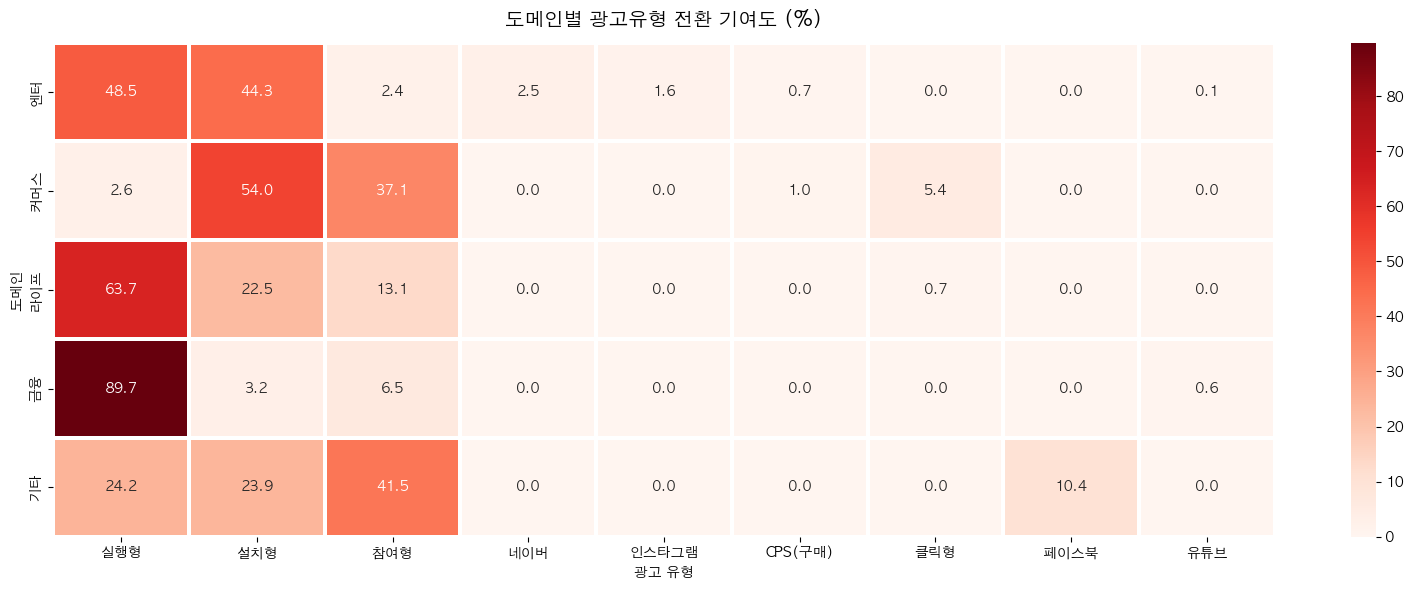


[② 예산 투입 비중 히트맵 (%)]
type_name     실행형   설치형   참여형  네이버  인스타그램  CPS(구매)  클릭형  페이스북  유튜브
domain_name                                                       
엔터           27.6  15.0   2.7  1.2    0.7     52.7  0.0   0.0  0.0
커머스           0.4   6.2   8.5  0.0    0.0     85.0  0.0   0.0  0.0
라이프          46.3  13.0  40.2  0.0    0.0      0.4  0.0   0.0  0.0
금융           62.7   1.6  35.3  0.0    0.0      0.0  0.0   0.0  0.3
기타           27.5  20.7  31.2  0.0    0.0      0.0  0.0  20.6  0.0


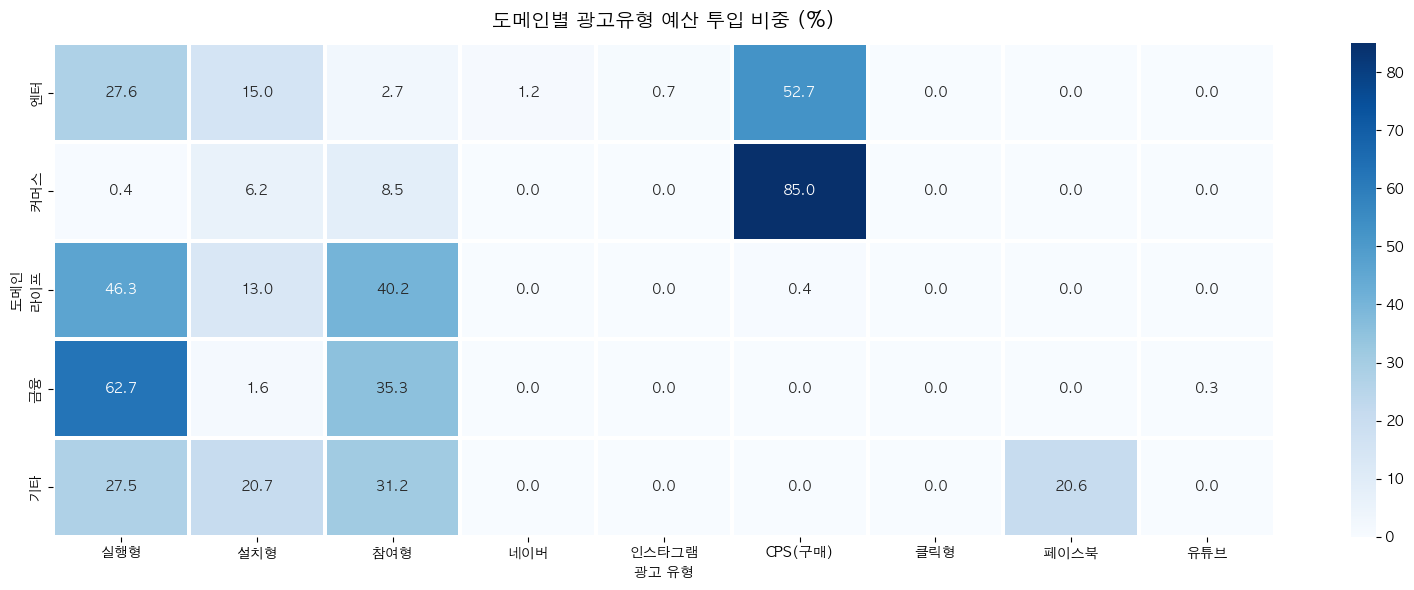


[③ 비용 효율 기여도 히트맵 (적립 건수 기준) (%)]
type_name     실행형   설치형   참여형  네이버  인스타그램  CPS(구매)  클릭형  페이스북  유튜브
domain_name                                                       
엔터           48.5  44.3   2.4  2.5    1.6      0.7  0.0   0.0  0.1
커머스           2.6  54.0  37.1  0.0    0.0      1.0  5.4   0.0  0.0
라이프          63.7  22.5  13.1  0.0    0.0      0.0  0.7   0.0  0.0
금융           89.7   3.2   6.5  0.0    0.0      0.0  0.0   0.0  0.6
기타           24.2  23.9  41.5  0.0    0.0      0.0  0.0  10.4  0.0


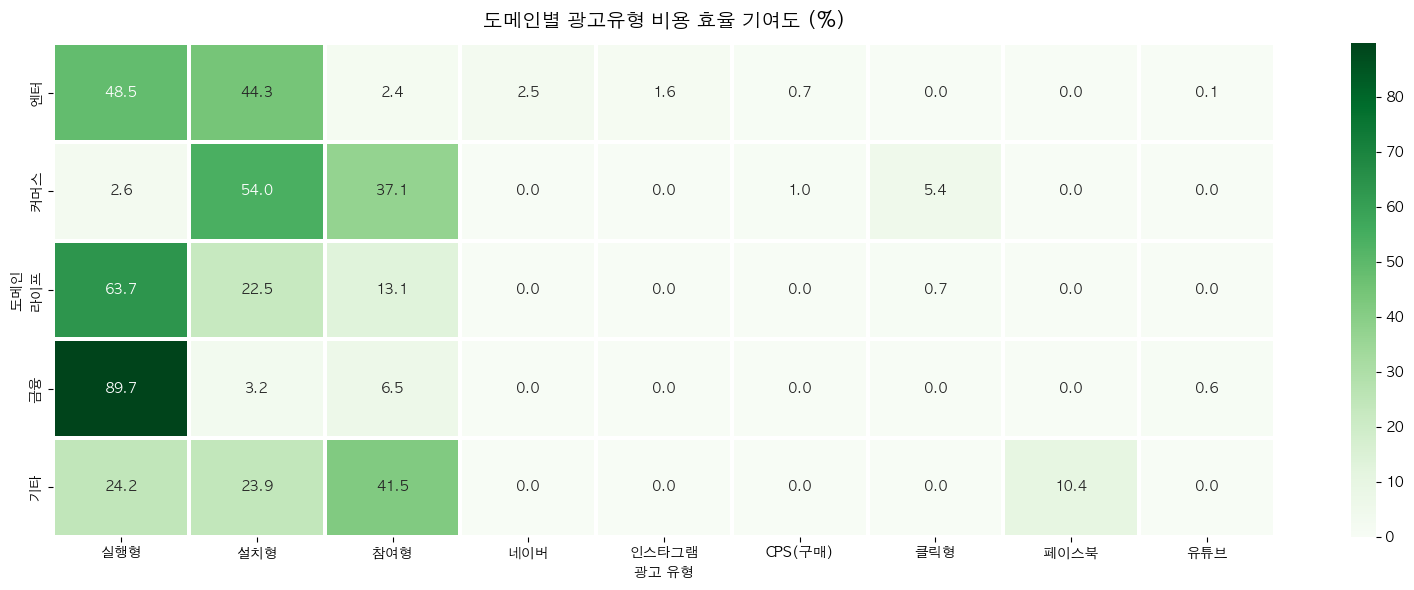

In [45]:
# reward_clean에 domain_label, ads_type이 이미 있으므로 merge 불필요
df_analysis = reward_clean.copy()
df_analysis['domain_name'] = df_analysis['domain_label'].map(domain_map)
df_analysis['type_name']   = df_analysis['ads_type'].map(type_map).fillna('unclassified')

# ① Conversion contribution heatmap (비율 %)
pivot_df = df_analysis.groupby(['domain_name', 'type_name']).size().unstack(fill_value=0)
conv_pct = (pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100).round(1)
conv_pct = conv_pct.reindex([r for r in ROW_ORDER if r in conv_pct.index])
conv_pct = conv_pct[[c for c in COL_ORDER if c in conv_pct.columns]]

print("[① Conversion contribution heatmap (%)]")
print(conv_pct.to_string())

plt.figure(figsize=(16, 6))
ax = sns.heatmap(conv_pct, annot=True, fmt='.1f', cmap='Reds',
                 linewidths=1.5, linecolor='white', annot_kws={"weight": "bold"})
plt.title('Conversion contribution by domain × ad type (%)', fontsize=14, pad=12)
plt.xlabel('ad type'); plt.ylabel('domain')
plt.tight_layout(); plt.show()

# ② Budget allocation heatmap
type_cost_dist = df_analysis.groupby(['domain_name', 'type_name'])['show_cost'].sum().unstack(fill_value=0)
type_cost_pct  = (type_cost_dist.div(type_cost_dist.sum(axis=1), axis=0) * 100).round(1)
type_cost_pct  = type_cost_pct.reindex([r for r in ROW_ORDER if r in type_cost_pct.index])
type_cost_pct  = type_cost_pct[[c for c in COL_ORDER if c in type_cost_pct.columns]]

print("\n[② Budget allocation heatmap (%)]")
print(type_cost_pct.to_string())

plt.figure(figsize=(16, 6))
ax = sns.heatmap(type_cost_pct, annot=True, fmt='.1f', cmap='Blues',
                 linewidths=1.5, linecolor='white', annot_kws={"weight": "bold"})
plt.title('Budget allocation by domain × ad type (%)', fontsize=14, pad=12)
plt.xlabel('ad type'); plt.ylabel('domain')
plt.tight_layout(); plt.show()

# ③ Cost efficiency contribution heatmap (click_key count = conversion count)
eff_dist = (
    df_analysis
    .groupby(['domain_name', 'type_name'])
    .agg(total_conv=('click_key', 'count'))   # rwd_idx 없음 → click_key 사용
    .reset_index()
)
conv_contribution = eff_dist.pivot(index='domain_name', columns='type_name', values='total_conv').fillna(0)
conv_pct2 = (conv_contribution.div(conv_contribution.sum(axis=1), axis=0) * 100).round(1)
conv_pct2 = conv_pct2.reindex([r for r in ROW_ORDER if r in conv_pct2.index])
conv_pct2 = conv_pct2[[c for c in COL_ORDER if c in conv_pct2.columns]]

print("\n[③ Cost efficiency contribution heatmap (based on reward count) (%)]")
print(conv_pct2.to_string())

plt.figure(figsize=(16, 6))
ax = sns.heatmap(conv_pct2, annot=True, fmt='.1f', cmap='Greens',
                 linewidths=1.5, linecolor='white', annot_kws={"weight": "bold"})
plt.title('Cost efficiency contribution by domain × ad type (%)', fontsize=14, pad=12)
plt.xlabel('ad type'); plt.ylabel('domain')
plt.tight_layout(); plt.show()

In [46]:
# 데이터 준비
needed_cols = ['ads_idx', 'domain_label', 'ads_type', 'ads_order', 'ads_name']
df_master_small = df_master[needed_cols].copy()
df_master_small['domain_name'] = df_master_small['domain_label'].map(domain_map)
df_master_small['type_name']   = df_master_small['ads_type'].map(type_map)

# domain 재분류 (ad명 기반 예외 처리)
df_master_small.loc[df_master_small['ads_name'].str.contains('원스토어', na=False), 'domain_name'] = 'enter'
for kw in ['에어매쉬토퍼', '시어서커 패드', '바디필로우', '마사지건', '다이어트']:
    df_master_small.loc[df_master_small['ads_name'].str.contains(kw, na=False), 'domain_name'] = 'commerce'

# 실적 있는 ad만 병합
df_master_active = df_master_small[df_master_small['ads_idx'].isin(reward_clean['ads_idx'].unique())]
df_final = pd.merge(reward_clean, df_master_active, on='ads_idx', how='inner')  # abusing removed

# 집계
eff_dist = df_final.groupby(['domain_name', 'type_name']).agg(
    total_conv =('click_key', 'count'),   # reward_clean: click_key count = conversion count
    total_spend=('show_cost', 'sum')
).reset_index()

conv_pivot  = eff_dist.pivot(index='domain_name', columns='type_name', values='total_conv').fillna(0)
spend_pivot = eff_dist.pivot(index='domain_name', columns='type_name', values='total_spend').fillna(0)

conv_pct   = conv_pivot.div(conv_pivot.sum(axis=1),   axis=0) * 100
spend_pct  = spend_pivot.div(spend_pivot.sum(axis=1), axis=0) * 100

# Strategic Importance = Geometric Mean(conversion기여도, 예산소화력)
strategic_score = np.sqrt(conv_pct * spend_pct).fillna(0)

print("[Integrated diagnosis] domain별 type별 Strategic importance full ranking")
domain_top_bottom = {}
for domain in strategic_score.index:
    full_rank  = strategic_score.loc[domain].sort_values(ascending=False)
    valid_rank = full_rank[full_rank > 0]
    print(f"\n[{domain}]")
    for i, (t_name, score) in enumerate(full_rank.items()):
        print(f"  {i+1}위: {t_name} ({score:.1f}점)")
    domain_top_bottom[domain] = {
        'top_1'   : valid_rank.index[0]  if not valid_rank.empty else 'N/A',
        'bottom_1': valid_rank.index[-1] if not valid_rank.empty else 'N/A'
    }

[통합 진단] 도메인별 유형별 전략적 중요도 전체 순위

[금융]
  1위: 실행형 (75.0점)
  2위: 참여형 (15.2점)
  3위: 설치형 (2.2점)
  4위: 유튜브 (0.5점)
  5위: CPS(구매) (0.0점)
  6위: 네이버 (0.0점)
  7위: 인스타그램 (0.0점)
  8위: 클릭형 (0.0점)
  9위: 페이스북 (0.0점)

[기타]
  1위: 참여형 (36.0점)
  2위: 실행형 (25.8점)
  3위: 설치형 (22.3점)
  4위: 페이스북 (14.6점)
  5위: CPS(구매) (0.0점)
  6위: 네이버 (0.0점)
  7위: 유튜브 (0.0점)
  8위: 인스타그램 (0.0점)
  9위: 클릭형 (0.0점)

[라이프]
  1위: 실행형 (55.5점)
  2위: 참여형 (23.5점)
  3위: 설치형 (15.5점)
  4위: 클릭형 (0.2점)
  5위: CPS(구매) (0.0점)
  6위: 네이버 (0.0점)
  7위: 유튜브 (0.0점)
  8위: 인스타그램 (0.0점)
  9위: 페이스북 (0.0점)

[엔터]
  1위: 실행형 (35.7점)
  2위: 설치형 (27.4점)
  3위: CPS(구매) (6.0점)
  4위: 참여형 (2.5점)
  5위: 네이버 (1.7점)
  6위: 인스타그램 (1.0점)
  7위: 유튜브 (0.0점)
  8위: 클릭형 (0.0점)
  9위: 페이스북 (0.0점)

[커머스]
  1위: 참여형 (24.1점)
  2위: CPS(구매) (12.5점)
  3위: 설치형 (4.9점)
  4위: 실행형 (1.3점)
  5위: 클릭형 (0.6점)
  6위: 네이버 (0.0점)
  7위: 유튜브 (0.0점)
  8위: 인스타그램 (0.0점)
  9위: 페이스북 (0.0점)


In [49]:
# ─────────────────────────────────────────────────────────
# STEP 22-8. Best-performing ad cases
# ─────────────────────────────────────────────────────────
# reward_clean에 없는 컬럼(ads_order, ads_sdate, ads_edate)만 df_master에서 추가
df_pattern = pd.merge(
    reward_clean,
    df_master[['ads_idx', 'ads_order', 'ads_sdate', 'ads_edate']],
    on='ads_idx', how='left'
)

# 날짜 필터 (click_date 기준)
if 'click_date' in df_pattern.columns:
    df_pattern['click_date'] = pd.to_datetime(df_pattern['click_date'], errors='coerce')
    df_pattern = df_pattern[
        (df_pattern['click_date'] >= ANALYSIS_START) &
        (df_pattern['click_date'] <= ANALYSIS_END)
    ]

df_pattern['effective_edate'] = df_pattern['ads_edate'].apply(
    lambda x: ANALYSIS_END if pd.notna(x) and x.year > 2026 else x
)
df_pattern['duration_days'] = (
    df_pattern['effective_edate'] - df_pattern['ads_sdate']
).dt.days.clip(lower=1)

df_pattern['reward_ratio'] = np.where(
    df_pattern['ads_contract_price'] > 0,
    df_pattern['ads_reward_price'] / df_pattern['ads_contract_price'], 0
)
df_pattern['domain_name'] = df_pattern['domain_label'].map(domain_map)
df_pattern['type_name']   = df_pattern['ads_type'].map(
    {1:'install', 2:'launch', 3:'participation', 4:'click_type', 12:'CPS(purchase)'}
)

# domain별 전략 1위 type
if 'domain_top_bottom' in dir() and domain_top_bottom:
    updated_top_1 = {d: v['top_1'] for d, v in domain_top_bottom.items() if v['top_1'] != 'N/A'}
else:
    updated_top_1 = {'finance':'launch','other':'launch','life':'launch','enter':'launch','commerce':'participation'}

print(f"[Best-performing ad cases] Top 5 by domain strategic #1 type")
print(f"  Target type: {updated_top_1}")

all_rankings = []
for domain, target_type in updated_top_1.items():
    subset = df_pattern[
        (df_pattern['domain_name'] == domain) & (df_pattern['type_name'] == target_type)
    ]
    if subset.empty:
        continue

    agg_dict = {
        'click_key'          : 'count',
        'show_cost'          : 'sum',
        'ads_contract_price' : 'max',
        'ads_order'          : 'mean',
        'ctit'               : 'median',
        'duration_days'      : 'max',
        'reward_ratio'       : 'mean'
    }
    final_agg = {k: v for k, v in agg_dict.items() if k in subset.columns}
    ad_rank = subset.groupby(['ads_idx', 'ads_name']).agg(final_agg).reset_index()
    ad_rank.rename(columns={'click_key': 'conv_count', 'ctit': 'ctit_sec_median'}, inplace=True)

    if 'ads_contract_price' in ad_rank.columns:
        ad_rank['total_cost']    = ad_rank['conv_count'] * ad_rank['ads_contract_price']
        ad_rank['cost_per_conv'] = ad_rank['ads_contract_price']
    else:
        ad_rank['total_cost'] = ad_rank['cost_per_conv'] = 0

    ad_rank = ad_rank.sort_values(by='conv_count', ascending=False).head(5)

    if not ad_rank.empty:
        ad_rank.insert(0, '순위', range(1, len(ad_rank) + 1))
        ad_rank.insert(1, 'domain', domain)
        all_rankings.append(ad_rank)
        print(f"\n[{domain} — {target_type}]")
        print(ad_rank.to_string(index=False))

if not all_rankings:
    print("condition에 맞는 우수 사례 데이터가 없습니다.")

[우수 광고 사례] 도메인별 전략 1위 유형 기준 상위 5개
  기준 유형: {'금융': '실행형', '기타': '참여형', '라이프': '실행형', '엔터': '실행형', '커머스': '참여형'}

[금융 — 실행형]
 순위 도메인  ads_idx     ads_name  conv_count  show_cost  ads_contract_price  ads_order  ctit_sec_median  duration_days  reward_ratio  total_cost  cost_per_conv
  1  금융   440167 [오픈하기] KB차차차       29706  7723560.0                 260  2747500.0             59.0            NaN      0.769231     7723560            260
  2  금융   439216    돈버는 날씨서비스        6080  1398400.0                 230  2747100.0            138.0            NaN      0.782609     1398400            230
  3  금융   133653        KB차차차        2399   623740.0                 300  2747800.0             56.0          237.0      0.733333      719700            300
  4  금융   431581    돈버는 날씨서비스        1516   348680.0                 230  2389400.0            150.0            NaN      0.782609      348680            230
  5  금융   355749    업비트 최초 열기        1108   265920.0                 240  2750800.0         

In [50]:
# conversion 키 set 생성
# abusing removed된 conversion 키 set 사용
conv_keys  = set(reward_clean['click_key'].values)
df_eng_tmp = event_clean[['ads_idx', 'click_key']].copy()
df_eng_tmp['is_churn'] = (~df_eng_tmp['click_key'].isin(conv_keys)).astype(int)

summary_lite = df_eng_tmp.groupby('ads_idx').agg(
    clicks=('click_key', 'count'),
    churns=('is_churn',  'sum')
).reset_index()

df_worst_all_domain = pd.merge(summary_lite, df_master_small, on='ads_idx', how='inner')
df_worst_all_domain['churn_rate'] = (
    df_worst_all_domain['churns'] / df_worst_all_domain['clicks']
) * 100

# churn률 100% ad
df_churn_100 = df_worst_all_domain[df_worst_all_domain['churn_rate'] == 100].copy()
churn_100_summary = df_churn_100.groupby('type_name').agg(
    case_count=('ads_idx', 'count')
).reset_index()
churn_100_summary['share'] = (
    churn_100_summary['case_count'] / churn_100_summary['case_count'].sum() * 100
).round(1)

print(f"[100% churn rate ad distribution]  총 {len(df_churn_100):,}건")
print(churn_100_summary.sort_values('case_count', ascending=False).to_string(index=False))

# domain × type별 분포
domain_type_churn = df_churn_100.groupby(['domain_name','type_name']).agg(
    case_count=('ads_idx','count')
).reset_index().sort_values(by=['domain_name','case_count'], ascending=[True, False])

print(f"\n[100% churn distribution by domain]")
print(domain_type_churn.to_string(index=False))

print("\n[요약] Most vulnerable ad type by domain")
print(domain_type_churn.groupby('domain_name').head(1).to_string(index=False))

[이탈률 100% 광고 분포]  총 1,283건
type_name  case_count  share
      참여형         894   69.7
  CPS(구매)         385   30.0
      실행형           4    0.3

[도메인별 이탈 100% 분포]
domain_name type_name  case_count
         금융       참여형          45
         금융   CPS(구매)           5
         금융       실행형           1
         기타       참여형         109
         기타   CPS(구매)           3
         기타       실행형           1
        라이프       참여형         393
        라이프   CPS(구매)          42
         엔터       참여형         155
        커머스   CPS(구매)         335
        커머스       참여형         192
        커머스       실행형           2

[요약] 도메인별 가장 취약한 광고 유형
domain_name type_name  case_count
         금융       참여형          45
         기타       참여형         109
        라이프       참여형         393
         엔터       참여형         155
        커머스   CPS(구매)         335


In [51]:
# ─────────────────────────────────────────────────────────
# STEP 22-10. 기회비용 집계
# 벡터 연산 버전: Python dict 루프 제거 → groupby로 100배+ 빠름
# ─────────────────────────────────────────────────────────
master_cols = ['ads_idx','ads_name','ads_order','ads_sdate','ads_edate',
               'ads_type','ads_reward_price','ads_contract_price','domain_label']
df_master_small2 = df_master[master_cols].copy()
df_master_small2['effective_edate'] = df_master_small2['ads_edate'].apply(
    lambda x: ANALYSIS_END if pd.notna(x) and x.year > 2026 else x
)
df_master_small2['domain_name'] = df_master_small2['domain_label'].map(domain_map)
df_master_small2['type_name']   = df_master_small2['ads_type'].map(
    {1:'install', 2:'launch', 3:'participation', 4:'click_type', 12:'CPS(purchase)'}
)

# conversion 키 set (abusing removed된 버전)
conv_keys_set = set(reward_clean['click_key'].values)

# event_clean 기준으로 Analysis period 필터 (이미 Analysis period 데이터이나 명시적 필터 유지)
eng_filtered = event_clean.copy()
if 'click_date' in eng_filtered.columns:
    eng_filtered['click_date'] = pd.to_datetime(eng_filtered['click_date'], errors='coerce')
    eng_filtered = eng_filtered[
        (eng_filtered['click_date'] >= ANALYSIS_START) &
        (eng_filtered['click_date'] <= ANALYSIS_END)
    ]

# churn 여부 + 손실액 파생변수 (벡터 연산)
eng_filtered = eng_filtered.copy()
eng_filtered['is_churn']  = (~eng_filtered['click_key'].isin(conv_keys_set)).astype(int)
# ads_contract_price: ad 계약단가 (df_engagement의 contract_price가 event_clean에 없으므로)
eng_filtered['lost_cost'] = eng_filtered['is_churn'] * eng_filtered['ads_contract_price'].fillna(0)

# ads_idx 단위 집계 (groupby 1회, Python 루프 없음)
summary_lite2 = (
    eng_filtered
    .groupby('ads_idx')
    .agg(
        clicks       = ('click_key', 'count'),
        churns       = ('is_churn',  'sum'),
        lost_revenue = ('lost_cost', 'sum')
    )
    .reset_index()
)

df_worst = pd.merge(summary_lite2, df_master_small2, on='ads_idx', how='inner')
df_worst['churn_rate']     = (df_worst['churns'] / df_worst['clicks']) * 100
df_worst['avg_lost_price'] = df_worst['lost_revenue'] / df_worst['churns'].replace(0, np.nan)

final_worst = df_worst[df_worst['clicks'] >= 10].sort_values(
    ['domain_name', 'churn_rate', 'clicks'], ascending=[True, False, False]
).groupby('domain_name').head(5)

output_cols = ['domain_name','type_name','ads_idx','ads_name',
               'clicks','churns','churn_rate','avg_lost_price','lost_revenue']
output_cols = [c for c in output_cols if c in final_worst.columns]
print("[Worst churn ads by domain (10+ clicks, Top 5 per domain)]")
print(final_worst[output_cols].to_string(index=False))


[도메인별 이탈 워스트 광고 (클릭 10건 이상, 도메인별 Top 5)]
domain_name type_name  ads_idx                                      ads_name  clicks  churns  churn_rate  avg_lost_price  lost_revenue
         금융       참여형   439990                                하나손보 자동차 보험 가입    4133    4133       100.0             0.0             0
         금융       참여형   103599                                        로보주식플랜     688     688       100.0             0.0             0
         금융       참여형   429011                                     웰로 고향사랑기부     173     173       100.0             0.0             0
         금융       참여형   443750                      AIA 보험상담 상담신청(30-65세 여성)     129     129       100.0             0.0             0
         금융       참여형   390849                          (무)ABL인터넷치아보험IV(갱신형)      67      67       100.0             0.0             0
         기타       참여형   313780                                   The Farmers 1625596 1625596       100.0             0.0             0
         기타   

In [52]:
# event_clean / reward_clean 사용 (abusing removed된 데이터 기준)
df_eng_counts = event_clean.groupby('ads_idx').size().reset_index(name='click_count')
df_rwd_counts = reward_clean.groupby('ads_idx').size().reset_index(name='reward_count')

df_funnel = pd.merge(df_master_small, df_eng_counts, on='ads_idx', how='left').fillna(0)
df_funnel = pd.merge(df_funnel, df_rwd_counts, on='ads_idx', how='left').fillna(0)

total_clicks  = int(df_funnel['click_count'].sum())
total_rewards = int(df_funnel['reward_count'].sum())
total_churns  = total_clicks - total_rewards

fig = go.Figure(go.Funnel(
    y=['Total Clicks (Engagement)', 'Conversion Success'],
    x=[total_clicks, total_rewards],
    textinfo='value+percent initial',
    marker={'color': ['#636EFA', '#00CC96']},
    connector={'line': {'color': 'royalblue', 'width': 2}}
))
fig.update_layout(title_text='Ad Funnel: Conversion & Churn')
fig.show()

cvr        = (total_rewards / total_clicks * 100) if total_clicks > 0 else 0
churn_rate = 100 - cvr

print("=== Ad funnel stage analysis report ===")
print(f"  Total clicks: {total_clicks:,}건  (100%)")
print(f"  Conversions: {total_rewards:,}건  ({cvr:.2f}%)")
print(f"  churn:      {total_churns:,}건  ({churn_rate:.2f}%)")
print(f"\n  Final CVR: {cvr:.2f}% / Potential churn loss: {total_churns:,}건")

=== 광고 퍼널 단계별 수치 분석 리포트 ===
  전체 클릭: 10,443,152건  (100%)
  적립 성공: 939,742건  (9.00%)
  이탈:      9,503,410건  (91.00%)

  최종 CVR: 9.00% / 이탈 잠재 손실: 9,503,410건


In [53]:
# domain_map_full: 긴 이름 버전 (어뷰징 분석의 domain_name_map과 동일)
domain_map_full = {1:'entertainment', 2:'finance', 3:'lifestyle', 4:'commerce', 5:'other'}

active_ads_ids = df_engagement['ads_idx'].unique()
df_master['is_active'] = df_master['ads_idx'].isin(active_ads_ids)

total_ads_cnt = len(df_master)
dead_copy_cnt = (~df_master['is_active']).sum()
print(f"Total ads: {total_ads_cnt:,}건 / Inactive ads(dead copy): {dead_copy_cnt:,}건 ({dead_copy_cnt/total_ads_cnt*100:.2f}%)")

# 참여형(type=3) deep-dive analysis
participation_ads      = df_master[df_master['ads_type'] == 3].copy()
dead_participation_cnt = (~participation_ads['is_active']).sum()
print(f"Total participation-type: {len(participation_ads):,}건 / 데드: {dead_participation_cnt:,}건 ({dead_participation_cnt/len(participation_ads)*100:.2f}%)")

dead_by_domain = (
    participation_ads[~participation_ads['is_active']]
    .groupby('domain_label').size().reset_index(name='dead_count')
)
dead_by_domain['domain_name'] = dead_by_domain['domain_label'].map(domain_map_full)
print("\ndomain별 참여형 dead copy 분포")
print(dead_by_domain.sort_values('dead_count', ascending=False)[['domain_name','dead_count']].to_string(index=False))

print("\nTotal participation-type ads_order 기초 통계")
print(participation_ads['ads_order'].describe())
print("\n참여형 Active ad ads_order distribution")
print(participation_ads[participation_ads['is_active']]['ads_order'].describe())

print("\nAll ads ads_order basic stats")
print(df_master['ads_order'].describe())
print("\nActive ad ads_order distribution")
print(df_master[df_master['is_active']]['ads_order'].describe())
print("\nZero-performance ad ads_order distribution")
print(df_master[~df_master['is_active']]['ads_order'].describe())

# type별 dead copy vs 활성 카피 점유율
df_dead   = df_master[~df_master['is_active']].copy()
df_active = df_master[df_master['is_active']].copy()

type_dead_stats = df_dead.groupby('ads_type').size().reset_index(name='dead_count')
type_dead_stats['type_name']     = type_dead_stats['ads_type'].map(type_map)
type_dead_stats['share_percent'] = (type_dead_stats['dead_count'] / type_dead_stats['dead_count'].sum() * 100).round(1)

type_active_stats = df_active.groupby('ads_type').size().reset_index(name='active_count')
type_active_stats['type_name']     = type_active_stats['ads_type'].map(type_map)
type_active_stats['share_percent'] = (type_active_stats['active_count'] / type_active_stats['active_count'].sum() * 100).round(1)

print(f"\n[ad type별 dead copy 점유율 (총 {type_dead_stats['dead_count'].sum():,}건)]")
print(type_dead_stats.sort_values('dead_count', ascending=False)[['type_name','dead_count','share_percent']].to_string(index=False))

print(f"\n[Active copy share by ad type (총 {type_active_stats['active_count'].sum():,}건)]")
print(type_active_stats.sort_values('active_count', ascending=False)[['type_name','active_count','share_percent']].to_string(index=False))

전체 운영 광고: 13,165건 / 무반응 광고(데드 카피): 3,757건 (28.54%)
참여형 전체: 11,661건 / 데드: 2,830건 (24.27%)

도메인별 참여형 데드 카피 분포
domain_name  dead_count
     엔터테인먼트        1048
     라이프스타일         831
        커머스         401
         금융         352
         기타         198

참여형 전체 ads_order 기초 통계
count    1.166100e+04
mean     1.552006e+06
std      3.907058e+05
min      7.391000e+05
25%      1.369622e+06
50%      1.369916e+06
75%      1.369937e+06
max      2.764300e+06
Name: ads_order, dtype: float64

참여형 활성 광고 ads_order 분포
count    8.831000e+03
mean     1.430996e+06
std      2.576326e+05
min      1.201938e+06
25%      1.369622e+06
50%      1.369869e+06
75%      1.369936e+06
max      2.764300e+06
Name: ads_order, dtype: float64

전체 광고 ads_order 기초 통계
count    1.316500e+04
mean     1.593998e+06
std      4.219162e+05
min      7.198000e+05
25%      1.369610e+06
50%      1.369936e+06
75%      1.552927e+06
max      2.764300e+06
Name: ads_order, dtype: float64

활성 광고 ads_order 분포
count    9.408000e+03
mean     1.

## STEP 22-13. Ad Exposure Order (ads_order) × Conversion Range Analysis

Key PPT insight: conversion occurrence pattern by exposure order.  
Quantify "no response below a certain exposure order".

In [54]:
# =========================================================
# STEP 22-13. ad 노출 순서(ads_order) × conversion 발생 구간 분석
# PPT 인사이트: "노출 순위 72만 미만 ad 반응 없음 / conversion 270만 번대 집중"
# =========================================================
order_bins   = [0, 500_000, 1_000_000, 1_500_000, 2_000_000, 2_500_000, 3_500_000]
order_labels = ['0~50만', '50~100만', '100~150만', '150~200만', '200~250만', '250만+']

# ad 단위 클릭/conversion 집계 (event_clean 기준)
ads_clk_cnt = event_clean.groupby('ads_idx').agg(
    clicks      = ('click_key', 'count'),
    conversions = ('is_conv',   'sum')
).reset_index()

order_df = df_master[['ads_idx', 'ads_order', 'ads_type_name', 'domain_name']].copy()
order_df  = order_df.merge(ads_clk_cnt, on='ads_idx', how='left').fillna(0)
order_df['order_group'] = pd.cut(
    order_df['ads_order'], bins=order_bins, labels=order_labels, right=True
)
order_df['has_click'] = order_df['clicks'] > 0
order_df['has_conv']  = order_df['conversions'] > 0

# 구간별 요약
order_summary = order_df.groupby('order_group', observed=False).agg(
    total_ads      = ('ads_idx',      'count'),
    ads_with_click = ('has_click',    'sum'),
    ads_with_conv  = ('has_conv',     'sum'),
    total_clicks   = ('clicks',       'sum'),
    total_conv     = ('conversions',  'sum'),
).reset_index()
order_summary['click_rate'] = (order_summary['ads_with_click'] / order_summary['total_ads'] * 100).round(1)
order_summary['conv_rate']  = (order_summary['ads_with_conv']  / order_summary['total_ads'] * 100).round(1)
order_summary['cvr']        = (order_summary['total_conv'] / order_summary['total_clicks'].replace(0, np.nan) * 100).round(2)

print("[Conversion analysis by ad exposure order range]")
print(f"{'구간':^10} {'총ad':>6} {'클릭발생':>8} {'클릭율':>7} {'conversion발생':>8} {'conversion율':>7} {'CVR%':>7}")
print("-" * 62)
for _, r in order_summary.iterrows():
    print(f"  {str(r['order_group']):^10} {r['total_ads']:>6,.0f}  {r['ads_with_click']:>7,.0f}  "
          f"{r['click_rate']:>6.1f}%  {r['ads_with_conv']:>7,.0f}  {r['conv_rate']:>6.1f}%  {r['cvr']:>6.2f}%")

min_active = order_df[order_df['has_click']]['ads_order'].min()
min_conv   = order_df[order_df['has_conv']]['ads_order'].min()
peak_group = order_summary.loc[order_summary['total_conv'].idxmax(), 'order_group']
peak_cvr   = order_summary.loc[order_summary['total_conv'].idxmax(), 'cvr']

print(f"\n  Min exposure order with click response: {min_active:>10,.0f}")
print(f"  Min exposure order with conversion      : {min_conv:>10,.0f}")
print(f"  Peak conversion range                : {peak_group}  (CVR {peak_cvr:.2f}%)")

# domain별 ads_order 임계값
print("\n[domain별 Min exposure order with conversion]")
domain_threshold = (
    order_df[order_df['has_conv']]
    .groupby('domain_name')['ads_order']
    .min().reset_index()
    .rename(columns={'ads_order': 'min_conv_order'})
    .sort_values('min_conv_order')
)
print(domain_threshold.to_string(index=False))


[광고 노출 순서 구간별 전환 분석]
    구간        총광고     클릭발생     클릭율     전환발생     전환율    CVR%
--------------------------------------------------------------
    0~50만         0        0     nan%        0     nan%     nan%
   50~100만        8        4    50.0%        0     0.0%    0.00%
   100~150만   9,750    3,028    31.1%    2,104    21.6%   47.72%
   150~200만     462      184    39.8%       46    10.0%   19.43%
   200~250만   2,499      273    10.9%      118     4.7%    0.06%
    250만+       446      305    68.4%      243    54.5%   43.05%

  클릭 반응 발생 최소 노출 순서:    719,800
  전환 발생 최소 노출 순서      :  1,247,233
  전환 집중 구간                : 250만+  (CVR 43.05%)

[도메인별 전환 발생 최소 노출 순서]
domain_name  min_conv_order
        커머스         1247233
        라이프         1317965
         금융         1360091
         기타         1368422
         엔터         1369544


## STEP 22-14. Automatic PHASE Classification for Risky Media

Extends PPT's mda_539 PHASE analysis to all risky media.  
Automatic detection: PHASE 1(Dormant) / PHASE 2(Expansion) / PHASE 3(Explosion).

In [55]:
# =========================================================
# STEP 22-14. Automatic PHASE classification for risky media
# mda_539 단독 분석 → 전체 위험 매체로 확장
# PHASE 1(잠복) / PHASE 2(확장) / PHASE 3(폭발) 자동 판별
# =========================================================
def classify_phase(monthly_share: pd.Series) -> str:
    """월별 클릭 점유율 시계열 → PHASE 자동 분류"""
    if len(monthly_share) < 3:
        return "데이터 부족"
    recent_3   = monthly_share.tail(3).mean()
    historical = monthly_share.iloc[:-3].mean() if len(monthly_share) > 3 else monthly_share.mean()
    if historical == 0:
        return "PHASE 1 — 잠복" if recent_3 < 1 else "PHASE 3 — 폭발"
    ratio = recent_3 / historical
    if   ratio >= 5: return "PHASE 3 — 폭발"
    elif ratio >= 2: return "PHASE 2 — 확장"
    else:            return "PHASE 1 — 잠복"

danger_mdas = mda_score[
    mda_score['Risk_Label'].isin(['critical', 'risky'])
]['mda_idx'].tolist()

print(f"[Automatic PHASE classification for risky media]  대상: {len(danger_mdas)}개 매체")
print(f"{'mda_idx':>8}  {'위험등급':^8}  {'PHASE':^18}  {'average점유%':>9}  {'최근3월%':>9}  {'총클릭':>12}")
print("-" * 72)

phase_results = []
for mda_id in sorted(danger_mdas):
    mda_monthly = (
        report_master[report_master['mda_idx'] == mda_id]
        .groupby('year_month').agg(clk_mda=('rpt_time_clk','sum')).reset_index()
    )
    mda_monthly = (
        monthly_total[['year_month','total_clk']]
        .merge(mda_monthly, on='year_month', how='left')
        .fillna(0)
    )
    mda_monthly['clk_share'] = (
        mda_monthly['clk_mda'] / mda_monthly['total_clk'].replace(0, np.nan) * 100
    ).fillna(0)

    phase        = classify_phase(mda_monthly['clk_share'])
    avg_share    = mda_monthly['clk_share'].mean()
    recent_share = mda_monthly['clk_share'].tail(3).mean()
    total_clk_m  = int(mda_monthly['clk_mda'].sum())
    risk_label   = mda_score.loc[mda_score['mda_idx']==mda_id, 'Risk_Label'].values[0]

    phase_results.append({
        'mda_idx': mda_id, 'Risk_Label': risk_label, 'phase': phase,
        'avg_share': avg_share, 'recent_share': recent_share, 'total_clk': total_clk_m
    })
    print(f"  {mda_id:>6}  {risk_label:^8}  {phase:<18}  "
          f"{avg_share:>8.2f}%  {recent_share:>8.2f}%  {total_clk_m:>12,}")

phase_df = pd.DataFrame(phase_results)
print(f"\n[Media count by PHASE]")
print(phase_df['phase'].value_counts().to_string())
print(f"\n[PHASE 3 — Explosion media list]")
phase3 = phase_df[phase_df['phase'].str.contains('폭발')]
if phase3.empty:
    print("  없음")
else:
    print(phase3[['mda_idx','Risk_Label','avg_share','recent_share','total_clk']].to_string(index=False))


[위험 매체 침투 PHASE 자동 분류]  대상: 19개 매체
 mda_idx    위험등급          PHASE             평균점유%      최근3월%           총클릭
------------------------------------------------------------------------
      56     위험     PHASE 1 — 잠복            0.58%      0.46%       411,100
      58    매우위험    PHASE 1 — 잠복            9.08%      4.78%     6,792,490
     291     위험     PHASE 1 — 잠복            0.00%      0.00%           962
     294    매우위험    PHASE 1 — 잠복            0.10%      0.13%        64,824
     371     위험     PHASE 1 — 잠복            2.22%      1.16%     1,364,567
     384     위험     PHASE 1 — 잠복            0.48%      0.32%       331,137
     458     위험     PHASE 1 — 잠복            0.53%      0.09%       398,479
     482     위험     PHASE 1 — 잠복            0.02%      0.02%        13,029
     492     위험     PHASE 1 — 잠복            0.02%      0.02%        15,783
     539    매우위험    PHASE 3 — 폭발            6.73%     27.28%    14,145,788
     562    매우위험    PHASE 1 — 잠복            1.37%      0.81%       

## STEP 22-15. Domain × Ad Type Optimal Combo — Final Summary Table

Corresponds to PPT slide 36.  
Final proposal based on Strategic Importance Index (√Conv.Contribution × Budget.Absorption).

  도메인 × 광고유형 최적 조합 — 최종 제안 요약
  평가 기준: 전략적 중요도 = √(전환기여도% × 예산소화력%)
  (기하평균: 한쪽만 높은 유형의 과대평가 방지)

  도메인             1위(최적)         2위           3위             제외검토       
  ────────────────────────────────────────────────────────────────────
  금융               실행형          참여형          설치형             N/A        
  기타               참여형          실행형          설치형             N/A        
  라이프              실행형          참여형          설치형             N/A        
  엔터               실행형          설치형        CPS(구매)        인스타그램, 유튜브    
  커머스              참여형        CPS(구매)        설치형           실행형, 클릭형     

[전략적 중요도 점수표]
type_name     실행형   설치형   참여형  네이버  인스타그램  CPS(구매)  클릭형  페이스북  유튜브
domain_name                                                       
엔터           35.7  27.4   2.5  1.7    1.0      6.0  0.0   0.0  0.0
커머스           1.3   4.9  24.1  0.0    0.0     12.5  0.6   0.0  0.0
라이프          55.5  15.5  23.5  0.0    0.0      0.0  0.2   0.0  0.0
금융           75.0   2.2  15.2  0.0    0.0  

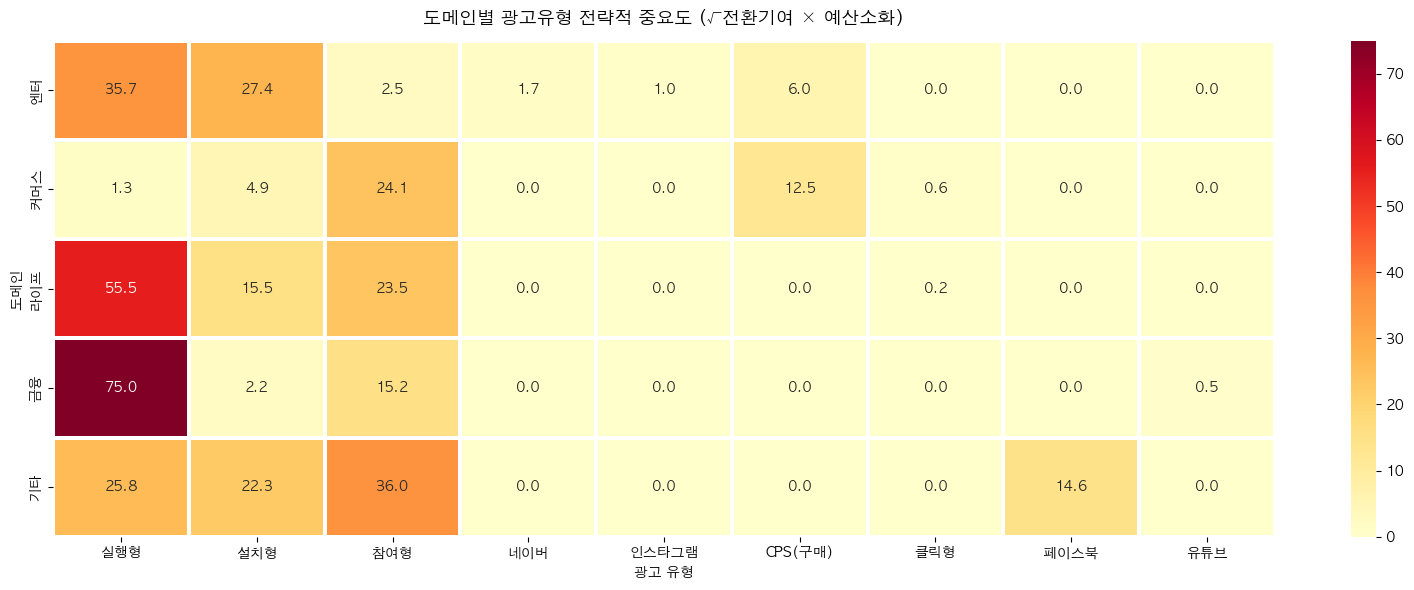

In [56]:
# =========================================================
# STEP 22-15. domain × adtype 최적 조합 최종 요약 테이블
# PPT 슬라이드 36 — 전략적 중요도 지수 기반 최종 제안
# =========================================================
print("=" * 68)
print("  Domain × Ad Type Optimal Combo — Final Proposal")
print("=" * 68)
print("  Evaluation: Strategic Importance = √(Conv.Contribution% × Budget.Absorption%)")
print("  (Geometric mean: prevents overrating types that are high in only one dimension)\n")
print(f"  {'domain':<12} {'1st(best)':^12} {'2위':^12} {'3위':^12} {'Consider Removing':^18}")
print("  " + "─" * 68)

final_summary = {}
for domain in strategic_score.index:
    ranked     = strategic_score.loc[domain].sort_values(ascending=False)
    valid      = ranked[ranked > 0]
    top3       = list(valid.index[:3]) + ['N/A'] * max(0, 3 - len(valid))
    exclude    = list(valid.index[-2:]) if len(valid) > 4 else ['N/A']
    print(f"  {domain:<12} {top3[0]:^12} {top3[1]:^12} {top3[2]:^12} {', '.join(exclude):^18}")
    final_summary[domain] = {'top_1': top3[0], 'top_2': top3[1], 'top_3': top3[2], 'exclude': exclude}

# 전략적 중요도 히트맵 시각화
all_types       = [t for t in COL_ORDER if t in strategic_score.columns]
strategic_disp  = (
    strategic_score[all_types]
    .reindex([r for r in ROW_ORDER if r in strategic_score.index])
    .round(1)
)

print(f"\n[Strategic importance score table]")
print(strategic_disp.to_string())

if not strategic_disp.empty:
    plt.figure(figsize=(16, 6))
    sns.heatmap(
        strategic_disp, annot=True, fmt='.1f', cmap='YlOrRd',
        linewidths=1.5, linecolor='white', annot_kws={"weight": "bold"}
    )
    plt.title('Strategic importance by domain × ad type (√conversion기여 × 예산소화)', fontsize=13, pad=12)
    plt.xlabel('ad type'); plt.ylabel('domain')
    plt.tight_layout(); plt.show()


## STEP 22-16. Full Analysis Pipeline Summary

Corresponds to PPT slide 16 — COMPLETED / IN PROGRESS / NEXT ACTION.

In [57]:
# =========================================================
# STEP 22-16. 전체 분석 파이프라인 요약
# PPT 슬라이드 16 — COMPLETED / IN PROGRESS / NEXT ACTION
# =========================================================
sep = "=" * 65

print(sep)
print("  Full Analysis Pipeline Summary — IVE KOREA Ad Optimization Project")
print(sep)

# ── [1] Abusing Detection ──────────────────────────────────────
total_integrated = len(df_integrated)
n_extreme  = (df_integrated['row_label'] == 'outlier').sum()
n_abusing  = (df_integrated['row_label'] == 'abusing').sum()
n_normal   = (df_integrated['row_label'] == 'normal').sum()
n_danger   = (mda_score['Risk_Label'] == 'critical').sum()

print("\n[1] Abusing Detection  ✅ COMPLETED")
print(f"  Detection criteria  : CTIT 중앙값×0.1 / IP기기수 상위0.1% / IPclick_count 상위0.1%")
print(f"  Total clicks  : {total_integrated:>14,}건")
print(f"  극단값     : {n_extreme:>14,}건  ({n_extreme/total_integrated*100:.1f}%)  ← 확정 어뷰징 / 정산 차감")
print(f"  어뷰징     : {n_abusing:>14,}건  ({n_abusing/total_integrated*100:.1f}%)  ← 의심 / 모니터링")
print(f"  정상       : {n_normal:>14,}건  ({n_normal/total_integrated*100:.1f}%)")
print(f"  confirmed loss  : {confirmed_show_loss:>14,.0f}원")
print(f"  critical media: {n_danger}개")

# ── [2] Media Operations Management ───────────────────────────────────
total_mda     = len(mda_score)
rec_cnt = imp_cnt = red_cnt = 0
if 'all_mda_results' in dir() and all_mda_results:
    for df_d in all_mda_results.values():
        rec_cnt += int(df_d['operation_tag'].isin(['confirmed','potential']).sum())
        imp_cnt += int((df_d['operation_tag']=='improve_first').sum())
        red_cnt += int((df_d['operation_tag']=='reduce_candidate').sum())
    print(f"\n[2] Media Operations Management  ✅ COMPLETED")
    print(f"  Media analyzed     : {total_mda}개  (전 domain × adtype × 매체)")
    print(f"  Confirmed/Potential recommended: {rec_cnt}개  |  Improve first: {imp_cnt}개  |  Reduce candidates: {red_cnt}개")
else:
    print(f"\n[2] Media Operations Management  ⏳ IN PROGRESS  (STEP 21 실행 필요)")

# ── [3] Domain Ad Optimization ──────────────────────────────
print(f"\n[3] Domain Ad Optimization  ✅ COMPLETED")
if 'final_summary' in dir() and final_summary:
    print(f"  Optimal ad type by domain:")
    for domain, v in final_summary.items():
        print(f"    {domain:<12}: 1위 {v['top_1']:^10} 2위 {v['top_2']:^10} 3위 {v['top_3']:^10}")
if 'min_active' in dir():
    print(f"\n  ads_order insight:")
    print(f"    Min exposure order for click response: {min_active:,.0f}")
    print(f"    Min exposure order with conversion: {min_conv:,.0f}")

# ── NEXT ACTION ──────────────────────────────────────────
print(f"\n[NEXT ACTION]")
print(f"  → Build monthly automated abusing detection pipeline")
print(f"  → critical media {n_danger}개 continue intensive monitoring")
print(f"  → Optimal ad type by domain 기반 ad주 제안서 작성")
if 'min_conv' in dir():
    print(f"  → ads_order {min_conv:,.0f} Recommend focusing on ads above")
print(sep)


  전체 분석 파이프라인 요약 — IVE KOREA 광고 최적화 프로젝트

[1] 어뷰징 탐지  ✅ COMPLETED
  탐지 기준  : CTIT 중앙값×0.1 / IP기기수 상위0.1% / IP클릭수 상위0.1%
  전체 클릭  :     16,831,054건
  극단값     :      6,387,902건  (38.0%)  ← 확정 어뷰징 / 정산 차감
  어뷰징     :      7,782,515건  (46.2%)  ← 의심 / 모니터링
  정상       :        811,565건  (4.8%)
  확정 손실  :     67,083,271원
  매우위험 매체: 7개

[2] 운영 매체 관리  ✅ COMPLETED
  분석 매체     : 189개  (전 도메인 × 광고유형 × 매체)
  확정/잠재 추천: 398개  |  개선우선: 308개  |  축소후보: 595개

[3] 도메인 광고 최적화  ✅ COMPLETED
  도메인별 최적 광고유형:
    금융          : 1위    실행형     2위    참여형     3위    설치형    
    기타          : 1위    참여형     2위    실행형     3위    설치형    
    라이프         : 1위    실행형     2위    참여형     3위    설치형    
    엔터          : 1위    실행형     2위    설치형     3위  CPS(구매)  
    커머스         : 1위    참여형     2위  CPS(구매)   3위    설치형    

  ads_order 인사이트:
    클릭 반응 최소 노출 순서: 719,800
    전환 발생 최소 노출 순서: 1,247,233

[NEXT ACTION]
  → 월별 어뷰징 자동 탐지 파이프라인 구축
  → 매우위험 매체 7개 집중 감시 지속
  → 도메인별 최적 광고유형 기반 광고주 제안서 작성
  → ads_order 1,247,233 이상 광고 집중 편성 권고